# DAPS for 3D Photon Flux Estimation (Poisson SPAD)

This notebook adapts **Decoupled Annealing Posterior Sampling** (DAPS, Zhang et al., CVPR 2025) to the SPAD photon-flux inverse problem with a **soft-blended** spatio-temporal prior, **photon-count pooling** on the data term, and — as Tier-B — the **evidence trick** of Micheli et al. 2025 ("Diffusion Models for Inverse Problems in the Exponential Family"): trained amortized-VI nets give a per-voxel **Gamma belief** $q(\theta\mid x_t)$, and the inner data step becomes the **exact Poisson–Gamma conjugate posterior draw** (`INNER_MODE = "conjugate"`), replacing the PF-ODE + Langevin machinery entirely.

## Why DAPS (and not DiffPIR) for this problem
DiffPIR's data step is a *proximal minimization* of the Poisson NLL.  At low photons-per-pixel (PPP ≤ 0.001) the NLL surface is flat and the proximal step pulls $\hat x_0$ toward the MAP of the binary SPAD observations.  DAPS replaces that minimization with sampling from
$$p(x_0\mid x_t,y)\;\propto\; p(x_0\mid x_t)\,p(y\mid x_0),$$
anchored on the diffusion-prior estimate.  The sampling (Langevin in Tier-A, exact conjugate draw in Tier-B) prevents collapse to the data MAP, and the *decoupled* annealing schedule lets the trajectory explore distinct posterior modes between annealing steps.

## Forward model (Poisson SPAD)
Let $x\in\mathbb{R}^{T\times H\times W}$ be the **normalized log-flux** in $[-1,1]$, with the affine map
$$\log\phi = \tfrac{L}{2}(x+1),\qquad L=\log\phi_{\max}.$$
Per voxel the SPAD bin count obeys
$$N_{kij}\;\sim\;\mathrm{Poisson}\big(\mu_{kij}\big),\qquad \mu_{kij}=B_k\,(\alpha\,\phi_{kij}+d),$$
where $B_k$ is frames-per-bin, $\alpha$ the per-frame detection rate (`ppp_scale`), and $d$ the dark count.  The log-likelihood is **fully voxel-wise separable**, so the score has a closed form:
$$\partial_{x_{kij}}\log p(N\mid x)\;=\;\Big(\tfrac{N_{kij}}{\mu_{kij}}-1\Big)\,B_k\,\alpha\,\phi_{kij}\,\tfrac{L}{2}.$$
No autograd is needed.  A **pooled** variant (§8) sums counts and exposures over groups of bins (the Poisson sufficient statistic) so the data term constrains only the pooled mean — injecting coupling at high noise.  In Tier-B the same separability + conjugacy makes the data step **exact and closed-form** (§10b).

## Spatio-temporal prior composition
We compose the spatial (2D) and temporal (1D) priors with a **soft blend** in EDM-sigma space, replacing the original hard switch.  The two $\varepsilon$-predictions are mixed by a smooth sigmoid weight centred at $\sigma^{*}$:
$$\varepsilon_{\mathrm{comp}}(x_t,t)=w(\sigma)\,\varepsilon_{S}(x_t,t)+\bigl(1-w(\sigma)\bigr)\,\varepsilon_{T}(x_t,t),\qquad w(\sigma)=\mathrm{sigmoid}\!\left(\tfrac{\log\sigma-\log\sigma^{*}}{h}\right).$$
As $h\to0$ this recovers the hard switch $s_{\mathrm{comp}}=s_S\,[\sigma\ge\sigma^{*}]+s_T\,[\sigma<\sigma^{*}]$.  Both priors were trained on the **same** synthetic SPAD dataset (normalized log-flux) and share the linear-1000 DDPM schedule, so their per-voxel marginals match: a convex blend is well-posed (no calibration or schedule bridge needed) and lets spatial and temporal coherence act **simultaneously** in the crossover band — which is precisely what suppresses salt-and-pepper impulses that violate both spatial *and* temporal smoothness.  To keep cost near $1\times$, both priors are evaluated only inside a band $[\sigma^{*}/\beta,\ \sigma^{*}\beta]$ (`BLEND_BAND`$=\beta$); outside it a single dominant prior is used.  The AVI Gamma beliefs of Tier-B are composed with the **same** blend weight, as a log-opinion pool in Gamma natural-parameter space (§10b).

## 1. Imports and device setup

In [1]:
import os
import sys
import math
import numpy as np
# os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
# os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
# os.environ["CUDA_VISIBLE_DEVICES"] = "1" 
import torch
import torch.nn.functional as F
from contextlib import nullcontext as _nullcontext
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# improved-diffusion (1D temporal prior)
sys.path.insert(0, '/u/scratch1/tan583/improved-diffusion-main')
from improved_diffusion.temporal_script_util import (
    temporal_model_and_diffusion_defaults,
    create_temporal_model_and_diffusion,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True   # autotune convs for the fixed 256x256 / 1024 shapes
torch.manual_seed(42); np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

/homes/tan583/scratch/condaenvs/DAPS/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


## 2. Hyperparameters

**Problem geometry & forward model** (kept identical to the DiffPIR notebook for direct comparison).

In [2]:
# -------------------- Problem geometry --------------------
VOL_T = 1024            # temporal resolution (matches 1D prior)
VOL_H = 256             # spatial height (matches 2D prior training res)
VOL_W = 256             # spatial width
T_TOTAL = 1.0
DT = T_TOTAL / VOL_T

# -------------------- Diffusion prior schedule (shared 1D & 2D) --------------------
NUM_DIFFUSION_STEPS = 1000
noise_schedule_1d   = "linear"
channel_mult_1d     = "1,2,3,4"
attention_resolutions_1d = "256, 128"
NUM_CHANNELS_1D     = 64

# -------------------- log-flux normalisation --------------------
LOG_FLUX_MAX = float(np.log(10000.0))   # the priors were trained on log-flux in [0, L] mapped to [-1, 1]
HALF_SCALE   = LOG_FLUX_MAX / 2.0

def normalize_log_flux(lf):
    return 2.0 * lf / LOG_FLUX_MAX - 1.0

def denormalize_log_flux(xn):
    return (xn + 1.0) * HALF_SCALE

# -------------------- SPAD forward model --------------------
TARGET_PPP    = 0.001
DARK_COUNT    = 0.0
N_SPAD_FRAMES = 100_000

# -------------------- DAPS sampler hyperparameters --------------------
# Outer annealing loop -- selects sigma values from the DDPM schedule.
DAPS_NUM_ANNEALING   = 100      # number of annealing steps (analogue of DiffPIR's NUM_SAMPLING_STEPS)

# Inner reverse PF-ODE (DDIM, deterministic) -- takes x_t at sigma_t down to ~0.
DAPS_NUM_INNER_PFODE = 5        # 1 = pure Tweedie; 3-10 gives DAPS its decoupled character

# Langevin MCMC -- samples x_0 from p(x_0 | x_t, y), anchored at x0_hat.  (Tier-A path.)
DAPS_NUM_MCMC        = 40       # MCMC iterations per annealing step
DAPS_LR_INIT         = 1e-3     # Langevin step size at high noise
DAPS_LR_MIN          = 1e-5     # Langevin step size at low noise (linearly annealed)
DAPS_LAMBDA_DATA     = 1.0      # scalar weight on Poisson score (1.0 = principled posterior)
DAPS_CLIP_X          = True     # clamp x to [-1, 1] after each Langevin update (training-domain bound)

# -------------------- Prior composition: 2D spatial x 1D temporal --------------------
# COMPOSE_MODE = "poe"    : product-of-experts score at EVERY sigma,
#                             eps = L2*eps_2d + L1*eps_1d - (L2+L1-1)*eps_marg.
#                           Both experts vote at all noise levels: global TEMPORAL structure
#                           is decided at high sigma, where a switching schedule silences the
#                           1D expert (the temporal "lag" of the sigmoid runs).  The
#                           subtracted per-voxel marginal removes the Gaussian bulk both
#                           experts double-count (Naive-Bayes overlap fix) and restores the
#                           correct high-sigma limit: without it eps_2d + eps_1d ~ 2*eps
#                           there and the Tweedie estimate overshoots to -x.  The joint
#                           model p2^L2 * p1^L1 / pmarg^(L2+L1-1) is the perpendicular-
#                           factor prior of DiffusionMBIR / TPDM.
# COMPOSE_MODE = "sigmoid": legacy soft blend (sigmoid gate in log-sigma, knobs below).
COMPOSE_MODE     = "poe"
POE_LAMBDA_2D    = 1.0          # exponent on the 2D spatial expert
POE_LAMBDA_1D    = 1.0          # exponent on the 1D temporal expert
POE_MARG_CORRECT = True         # subtract (L2+L1-1) * per-voxel marginal score (keep True;
                                # the high-sigma limit is wrong without it)
MARG_FIT_FROM_COUNTS = True     # empirical-Bayes fit of the marginal N(m, s^2) from per-pixel
                                # photon TOTALS (~1000 counts/pixel at ppp=0.01 -> the MLE is
                                # well-conditioned).  False -> use the constants below.
                                # High-sigma behaviour is insensitive to (m, s); they matter
                                # mildly at mid sigma.
MARG_MEAN = 0.0                 # fallback marginal mean of normalized log-flux
MARG_STD  = 0.6                 # fallback marginal sd

# -------------------- Soft-blend knobs (COMPOSE_MODE="sigmoid" only) --------------------
# Sigmoid weight on the high-sigma-phase prior, in log-sigma. BLEND_H -> 0 = hard switch.
# TEMPORAL_FIRST = False : 2D spatial dominates at high sigma, 1D temporal at low sigma.
TEMPORAL_FIRST = False
SWITCH_SIGMA   = 0.5            # blend CENTRE in EDM-sigma space (w_high = 0.5 here)
BLEND_H        = 0.5            # crossover width in log-sigma; smaller = sharper (-> hard switch)
BLEND_BAND     = 2.0            # call BOTH priors only when sigma in [SWITCH/BAND, SWITCH*BAND]

# -------------------- Annealed-Langevin corrector (compositional sampling fix) --------------------
# A combination of noise-level-sigma expert scores is NOT the sigma-noised score of the
# composed model (Du et al., "Reduce, Reuse, Recycle", ICML 2023); a few ULA steps per
# annealing level targeting the composed score re-equilibrate the renoised iterate.
# Each step costs one full sweep of both experts, and the corrector is prior-only (the
# data enters through the conjugate step), so keep K small and restrict it to the
# low-sigma endgame.  0 disables (default -- enable if the PoE run still shows
# composition artifacts, e.g. spatio-temporal seams).
ULA_CORRECT_STEPS = 0           # K corrector steps per annealing level (try 2-5)
ULA_CORRECT_SIGMA = 0.5         # run the corrector only when sigma_next <= this
ULA_STEP_SCALE    = 0.1         # eta = ULA_STEP_SCALE * sigma_next^2

# -------------------- Photon-count pooling (RETIRED -- keep at 1) --------------------
# Legacy measurement-side aggregation: POOL_FACTOR consecutive bins shared one flux in the
# likelihood.  Retired in favour of the anchor concentration schedule (ANCHOR_SD_SCALE /
# ANCHOR_ALPHA_FLOOR below): the coarse-to-fine role now lives entirely on the PRIOR side
# and the likelihood is never modified.  1 disables (exact per-bin data).
POOL_FACTOR_INIT  = 1
POOL_FACTOR_FLOOR = 1

# -------------------- Tier-B: evidence trick (conjugate inner step) --------------------
# INNER_MODE = "conjugate": replace the PF-ODE + Langevin inner machinery with the trained
#              AVI Gamma nets + the EXACT Poisson-Gamma conjugate posterior draw (Prop. A.8,
#              Micheli et al. 2025). Forward passes only, zero inner iterations.
# INNER_MODE = "langevin" : Tier-A inner loop (PF-ODE anchor + analytic Poisson Langevin).
INNER_MODE        = "conjugate"
AVI_TRAINING_PATH = "/u/scratch1/tan583/SPADAPS/avi_training"    # dir with avi_gamma.py + run dirs
AVI_CHECKPOINT_2D = AVI_TRAINING_PATH + "/avi_spatial_256/ema_0.9999_020000.pt"   # <- EDIT: your latest spatial EMA
AVI_CHECKPOINT_1D = AVI_TRAINING_PATH + "/avi_temporal_1024/ema_0.9999_best.pt"   # <- EDIT: temporal EMA/best
AVI_RATE_LINK     = "normflux"  # MUST match training --rate_link (theta = phi/phi_max)
AVI_GAMMA_EPS     = 1e-4        # MUST match training --gamma_eps
CONJ_ANCHOR_WEIGHT = 1.0        # 1.0 = PF-ODE Gamma anchor ONLY: exact conjugate draw around the
                                # score-prior estimate; AVI nets bypassed and not even loaded.
                                # 0<w<1 log-opinion-pools anchor (w) with the AVI belief (1-w);
                                # 0 = pure AVI belief -- DIVERGED on the first cluster run at
                                # ppp=0.001 (diffuse, undertrained beliefs; see the 12b probe).
CONJ_FINAL_MEAN    = True       # final annealing step: exact posterior MEAN at pool=1 instead of
                                # a draw -- removes irreducible last-draw speckle from the output.

# -------- Anchor concentration schedule (belief-side annealing; replaces pooling) --------
# The Gamma anchor matches mean = g^{-1}(x0_hat) and sd(log theta) = (L/2)*ANCHOR_SD_SCALE*
# sigma_t (alpha = 1/Var(log theta)), so the belief TIGHTENS as the annealing descends and
# per-bin counts enter the posterior gradually -- prior-side coarse-to-fine with the
# likelihood left untouched.  ANCHOR_ALPHA_FLOOR >= 2 keeps the Gamma density ZERO at
# theta=0: the old floor of 1 (exponential belief) put mass at theta ~ 0, and in dark
# regions (posterior shape 1+Y, Y in {0,1}) the conjugate draws speckled (salt-&-pepper)
# with amplitude > sigma_next -- outliers the remaining annealing could never remove.
ANCHOR_ALPHA_FLOOR = 2.0        # was 1.0 (exponential; heavy tail at theta=0 -> pepper)
ANCHOR_SD_SCALE    = 0.5        # c in sd_x(belief) = c*sigma_t; c<1 ramps concentration earlier
ANCHOR_PFODE_SIGMA = 0.25       # sigma-adaptive anchor depth (conjugate mode): run the full
                                # DAPS_NUM_INNER_PFODE PF-ODE anchor only when sigma_t <= this;
                                # above it use ONE Tweedie step (the sd-matched anchor is
                                # deliberately diffuse at high sigma -- only its MEAN matters --
                                # so extra substeps buy nothing).  ~5x fewer prior sweeps.
                                # Set >= max(sigma_arr) to force full-depth PF-ODE every step.

# -------------------- Inference-speed knobs --------------------
PIXEL_CHUNK = 512               # 1D-prior batch over (H*W) pixel trajectories
FRAME_CHUNK = 32                # 2D-prior batch over T frames (32 known-good; 64 OOMs at 256-res:
                                # step 0 runs the 2D net over ALL frames at high sigma; a decoder
                                # ResBlock GroupNorm fp32 upcast is [chunk,512,256,256] -> chunk/32*4GiB.
                                # FIRST knob to lower if the 2D forward OOMs -- it fails on step 0.)
USE_AMP     = True              # autocast prior forwards to fp16 on CUDA (eval only, frozen weights)
AMP_DTYPE   = "fp16"            # "fp16" or "bf16"
USE_CHANNELS_LAST = True        # NHWC for 2D prior (Ampere+ cuDNN speedup)

# -------------------- Checkpoints --------------------
MODEL_CHECKPOINT_1D = "./improved-diffusion-main/models/1024_sim_normalized_linear/model020000.pt"
GD_REPO_PATH        = "/homes/tan583/scratch/guided-diffusion"
MODEL_CHECKPOINT_2D = "/u/scratch1/tan583/guided-diffusion/checkpoints/intensity_ft/model050000.pt"

print("Configuration")
print(f"  Volume                       : {VOL_T}x{VOL_H}x{VOL_W}")
print(f"  PPP / N_frames               : {TARGET_PPP} / {N_SPAD_FRAMES}")
print(f"  DAPS annealing / inner / MCMC: {DAPS_NUM_ANNEALING} / {DAPS_NUM_INNER_PFODE} / {DAPS_NUM_MCMC}")
print(f"  Langevin lr                  : {DAPS_LR_INIT} -> {DAPS_LR_MIN}")
if COMPOSE_MODE == "poe":
    print(f"  Composition                  : PoE  l2={POE_LAMBDA_2D}, l1={POE_LAMBDA_1D}, "
          f"marg_correct={POE_MARG_CORRECT} (fit_from_counts={MARG_FIT_FROM_COUNTS})")
else:
    print(f"  Composition                  : sigmoid blend  centre sigma*={SWITCH_SIGMA}, h={BLEND_H}, "
          f"band={BLEND_BAND}, temporal_first={TEMPORAL_FIRST}")
print(f"  ULA corrector                : K={ULA_CORRECT_STEPS}"
      + (f", sigma_next<={ULA_CORRECT_SIGMA}, eta={ULA_STEP_SCALE}*sigma^2"
         if ULA_CORRECT_STEPS > 0 else "  (off)"))
print(f"  Pooling (retired)            : {POOL_FACTOR_INIT} -> {POOL_FACTOR_FLOOR}")
print(f"  Inner mode                   : {INNER_MODE}"
      + (f"  (link={AVI_RATE_LINK}, anchor_w={CONJ_ANCHOR_WEIGHT}, final_mean={CONJ_FINAL_MEAN}, "
         f"anchor_pfode_sigma={ANCHOR_PFODE_SIGMA})"
         if INNER_MODE == "conjugate" else ""))
if INNER_MODE == "conjugate":
    print(f"  Anchor concentration         : alpha_floor={ANCHOR_ALPHA_FLOOR}, sd_scale={ANCHOR_SD_SCALE}"
          f"  (alpha rises above the floor once sigma_t < "
          f"{2.0 / (LOG_FLUX_MAX * ANCHOR_SD_SCALE * ANCHOR_ALPHA_FLOOR ** 0.5):.3f})")
print(f"  LOG_FLUX_MAX                 : {LOG_FLUX_MAX:.4f}")

Configuration
  Volume                       : 1024x256x256
  PPP / N_frames               : 0.001 / 100000
  DAPS annealing / inner / MCMC: 100 / 5 / 40
  Langevin lr                  : 0.001 -> 1e-05
  Composition                  : PoE  l2=1.0, l1=1.0, marg_correct=True (fit_from_counts=True)
  ULA corrector                : K=0  (off)
  Pooling (retired)            : 1 -> 1
  Inner mode                   : conjugate  (link=normflux, anchor_w=1.0, final_mean=True, anchor_pfode_sigma=0.25)
  Anchor concentration         : alpha_floor=2.0, sd_scale=0.5  (alpha rises above the floor once sigma_t < 0.307)
  LOG_FLUX_MAX                 : 9.2103


## 3. Load 1D temporal prior

Trained on per-pixel log-flux trajectories of length $T=1024$, normalized to $[-1,1]$.  Predicts the noise $\varepsilon$ at a given DDPM timestep ($\texttt{learn\_sigma}=\texttt{False}$).

In [3]:
def load_temporal_diffusion_model(checkpoint_path=None):
    defaults = temporal_model_and_diffusion_defaults()
    defaults.update({
        'sequence_length'      : VOL_T,
        'num_channels'         : NUM_CHANNELS_1D,
        'diffusion_steps'      : NUM_DIFFUSION_STEPS,
        'channel_mult'         : channel_mult_1d,
        'noise_schedule'       : noise_schedule_1d,
        'learn_sigma'          : False,
        'attention_resolutions': attention_resolutions_1d,
    })
    model_1d, diffusion_1d = create_temporal_model_and_diffusion(**defaults)
    if checkpoint_path and os.path.exists(checkpoint_path):
        print(f"Loading 1D checkpoint from {checkpoint_path}")
        sd = torch.load(checkpoint_path, map_location='cpu')
        model_1d.load_state_dict(sd)
    else:
        print(f"WARNING: 1D checkpoint not found at {checkpoint_path}; using random init.")
    model_1d = model_1d.to(device).eval()
    for p in model_1d.parameters():
        p.requires_grad = False
    return model_1d, diffusion_1d

model_1d, diffusion_1d = load_temporal_diffusion_model(MODEL_CHECKPOINT_1D)
print(f"1D prior params={sum(p.numel() for p in model_1d.parameters()):,}")

Loading 1D checkpoint from ./improved-diffusion-main/models/1024_sim_normalized_linear/model020000.pt
1D prior params=11,111,873


## 4. Load 2D spatial prior

Single-channel `guided_diffusion` UNet trained on per-frame normalized log-flux at $256\times 256$, **same dataset** as the 1D prior.  Predicts $\varepsilon$ and the per-pixel variance ($\texttt{learn\_sigma}=\texttt{True}$); we keep only the $\varepsilon$ half.

In [4]:
if GD_REPO_PATH not in sys.path:
    sys.path.insert(0, GD_REPO_PATH)
from guided_diffusion.script_util import (
    model_and_diffusion_defaults as gd_model_and_diffusion_defaults,
    create_model_and_diffusion   as gd_create_model_and_diffusion,
)

SPATIAL_2D_OVERRIDES = dict(
    image_size=256, in_channels=1, num_channels=256, num_res_blocks=2,
    num_head_channels=64, attention_resolutions="32,16,8",
    resblock_updown=True, use_scale_shift_norm=True,
    learn_sigma=True, class_cond=False,
    diffusion_steps=NUM_DIFFUSION_STEPS, noise_schedule="linear",
    use_fp16=False,
)

def load_spatial_diffusion_model(checkpoint, overrides):
    defaults = gd_model_and_diffusion_defaults(); defaults.update(overrides)
    model_2d, diffusion_2d = gd_create_model_and_diffusion(**defaults)
    if os.path.exists(checkpoint):
        print(f"Loading 2D checkpoint from {checkpoint}")
        sd = torch.load(checkpoint, map_location='cpu')
        model_2d.load_state_dict(sd)
    else:
        print(f"WARNING: 2D checkpoint not found at {checkpoint}; using random init.")
    model_2d = model_2d.to(device).eval()
    for p in model_2d.parameters():
        p.requires_grad = False
    if USE_CHANNELS_LAST:
        try:
            model_2d = model_2d.to(memory_format=torch.channels_last)
        except Exception as e:
            print(f"channels_last skipped: {e}")
    in_ch  = int(overrides["in_channels"])
    out_ch = 2 * in_ch if overrides.get("learn_sigma", False) else in_ch
    info   = dict(in_channels=in_ch, out_channels=out_ch,
                  learn_sigma=bool(overrides.get("learn_sigma", False)))
    return model_2d, diffusion_2d, info

model_2d, diffusion_2d, prior_info_2d = load_spatial_diffusion_model(
    MODEL_CHECKPOINT_2D, SPATIAL_2D_OVERRIDES)
print(f"2D prior in_ch={prior_info_2d['in_channels']} learn_sigma={prior_info_2d['learn_sigma']} "
      f"params={sum(p.numel() for p in model_2d.parameters()):,}")

Loading 2D checkpoint from /u/scratch1/tan583/guided-diffusion/checkpoints/intensity_ft/model050000.pt
2D prior in_ch=1 learn_sigma=True params=552,800,258


## 4b. Load AVI Gamma inference nets (Tier-B, evidence trick)

The amortized-VI inference nets $\zeta_\rho(x_t, t)$ (Micheli et al. 2025, §3.4) predict, per voxel, the hyperparameters $(\alpha, \beta)$ of a **Gamma belief** over the Poisson rate $\theta = g^{-1}(x_0)$ given the *noised* iterate $x_t$:
$$q\bigl(\theta \mid \zeta(x_t)\bigr) = \mathrm{Gamma}\bigl(\theta;\, \alpha(x_t),\, \beta(x_t)\bigr) \;\approx\; p(\theta \mid x_t).$$

They were trained with the simulation-free Eq.-13 objective (`avi_training/train_avi_{spatial,temporal}.py`) on the **same clean normalized-log-flux corpus** as the score priors, with the same backbones (ADM-256 and temporal-UNet-1024) and a 2-channel head ($\alpha_{\text{raw}}, \beta_{\text{raw}}$, mapped through softplus in `avi_gamma.gamma_params_from_output`).

The link is `normflux`: $\theta = \phi/\phi_{\max} \in (0,1]$, $\log\theta = (x_0 - 1)\,L/2$ — it **must** match training (`--rate_link`), as must `--gamma_eps`. `avi_gamma.py` is imported from `AVI_TRAINING_PATH` so training and inference share one implementation of the link, softplus, and conjugate update.

Nets are loaded only when `INNER_MODE = "conjugate"`; the Tier-A Langevin path needs neither.

In [5]:
# ---- Shared Poisson-Gamma utilities (single source of truth with AVI training) ----
if AVI_TRAINING_PATH not in sys.path:
    sys.path.insert(0, AVI_TRAINING_PATH)
import avi_gamma

def load_spatial_avi_net(checkpoint):
    """2D AVI inference net zeta_2d: same ADM backbone as the 2D score prior, 2-ch out."""
    defaults = gd_model_and_diffusion_defaults()
    defaults.update(SPATIAL_2D_OVERRIDES)          # includes learn_sigma=True -> out_channels = 2
    net, _ = gd_create_model_and_diffusion(**defaults)
    print(f"Loading 2D AVI checkpoint from {checkpoint}")
    sd = torch.load(checkpoint, map_location="cpu")
    net.load_state_dict(sd)
    net = net.to(device).eval()
    for p in net.parameters():
        p.requires_grad = False
    if USE_CHANNELS_LAST:
        try:
            net = net.to(memory_format=torch.channels_last)
        except Exception as e:
            print(f"channels_last skipped: {e}")
    return net

def load_temporal_avi_net(checkpoint):
    """1D AVI inference net zeta_1d: same temporal UNet as the 1D score prior, 2-ch out."""
    defaults = temporal_model_and_diffusion_defaults()
    defaults.update({
        'sequence_length'      : VOL_T,
        'num_channels'         : NUM_CHANNELS_1D,
        'diffusion_steps'      : NUM_DIFFUSION_STEPS,
        'channel_mult'         : channel_mult_1d,
        'noise_schedule'       : noise_schedule_1d,
        'learn_sigma'          : True,             # 2 output channels (alpha_raw, beta_raw)
        'attention_resolutions': attention_resolutions_1d,
    })
    net, _ = create_temporal_model_and_diffusion(**defaults)
    print(f"Loading 1D AVI checkpoint from {checkpoint}")
    sd = torch.load(checkpoint, map_location="cpu")
    net.load_state_dict(sd)
    net = net.to(device).eval()
    for p in net.parameters():
        p.requires_grad = False
    return net

zeta_2d = zeta_1d = None
if INNER_MODE == "conjugate" and CONJ_ANCHOR_WEIGHT < 1.0:
    zeta_2d = load_spatial_avi_net(AVI_CHECKPOINT_2D)
    zeta_1d = load_temporal_avi_net(AVI_CHECKPOINT_1D)
    print(f"AVI nets loaded: zeta_2d params={sum(p.numel() for p in zeta_2d.parameters()):,}  "
          f"zeta_1d params={sum(p.numel() for p in zeta_1d.parameters()):,}")
else:
    print("AVI nets not loaded (Tier-A Langevin path, or pure-anchor conjugate mode "
          "with CONJ_ANCHOR_WEIGHT=1.0; the 12b probe loads them on demand).")

AVI nets not loaded (Tier-A Langevin path, or pure-anchor conjugate mode with CONJ_ANCHOR_WEIGHT=1.0; the 12b probe loads them on demand).


## 5. Schedule (sanity check)

Both priors share the linear-1000 DDPM schedule, so the EDM-sigma arrays should agree to numerical precision.  We use a single `sigma_arr` indexed by $t\in\{0,\dots,999\}$ and a single `alphas_cumprod_t` for the EDM$\leftrightarrow$DDPM conversion in the inner PF-ODE.

In [6]:
alphas_cumprod_1d = np.asarray(diffusion_1d.alphas_cumprod, dtype=np.float64)
alphas_cumprod_2d = np.asarray(diffusion_2d.alphas_cumprod, dtype=np.float64)
sigma_1d = np.sqrt((1.0 - alphas_cumprod_1d) / alphas_cumprod_1d)
sigma_2d = np.sqrt((1.0 - alphas_cumprod_2d) / alphas_cumprod_2d)

max_dev = float(np.max(np.abs(sigma_1d - sigma_2d)))
print(f"sigma_1d range = [{sigma_1d[0]:.4f}, {sigma_1d[-1]:.4f}]")
print(f"sigma_2d range = [{sigma_2d[0]:.4f}, {sigma_2d[-1]:.4f}]")
print(f"max |sigma_1d - sigma_2d| = {max_dev:.2e}  -> schedules align" if max_dev < 1e-6
      else f"max |sigma_1d - sigma_2d| = {max_dev:.2e}  -> schedules differ; falling back to per-prior sigmas")

# Tensorise for repeated use
alphas_cumprod_t = torch.from_numpy(alphas_cumprod_1d).to(device).float()
sigma_arr        = torch.from_numpy(sigma_1d).to(device).float()

# Decide which sigma column to compare against SWITCH_SIGMA
SWITCH_T = int(np.searchsorted(sigma_1d, SWITCH_SIGMA))
SWITCH_T = max(0, min(SWITCH_T, len(sigma_1d) - 1))
print(f"SWITCH_SIGMA={SWITCH_SIGMA} -> SWITCH_T={SWITCH_T} (sigma_1d[T*]={sigma_1d[SWITCH_T]:.3f})")

sigma_1d range = [0.0100, 157.4073]
sigma_2d range = [0.0100, 157.4073]
max |sigma_1d - sigma_2d| = 0.00e+00  -> schedules align
SWITCH_SIGMA=0.5 -> SWITCH_T=145 (sigma_1d[T*]=0.503)


## 6. SPAD volume simulation

Per-frame Bernoulli with detection probability $1-e^{-N}$ aggregated to per-bin Binomial -- numerically equivalent to Poisson at the PPP regime we operate in (≤ 0.01).  Streamed per-frame to keep memory bounded.

In [7]:
def generate_spad_volume(flux_vol, target_ppp=TARGET_PPP, d=DARK_COUNT,
                          n_frames=N_SPAD_FRAMES, num_bins=None, seed=0, verbose=True):
    """
    flux_vol : [T,H,W] float32, linear flux in arbitrary units.
    Returns  : bin_counts [T,H,W] float32, bin_sizes [T] float32, ppp_scale (scalar).
    """
    if num_bins is None: num_bins = flux_vol.shape[0]
    Tvol, H, W   = flux_vol.shape
    rng          = np.random.default_rng(seed)
    flux_max     = float(flux_vol.max())
    I_norm       = (flux_vol / flux_max).astype(np.float32, copy=False)
    I_mean_glob  = float(I_norm.mean())
    a_scale      = target_ppp / max(I_mean_glob, 1e-12)
    ppp_scale_3d = a_scale / flux_max

    fpb_edges      = np.linspace(0, n_frames, num_bins + 1, dtype=np.int64)
    bin_sizes      = np.diff(fpb_edges).astype(np.int64)

    if num_bins != Tvol:
        t_src = np.linspace(0.0, 1.0, Tvol,    dtype=np.float32)
        t_dst = np.linspace(0.0, 1.0, num_bins, dtype=np.float32)
        I_use = np.empty((num_bins, H, W), dtype=np.float32)
        for i in range(H):
            for j in range(W):
                I_use[:, i, j] = np.interp(t_dst, t_src, I_norm[:, i, j])
    else:
        I_use = I_norm

    bin_counts = np.empty((num_bins, H, W), dtype=np.float32)
    a32 = np.float32(a_scale); d32 = np.float32(d)
    for k in range(num_bins):
        N_k = a32 * I_use[k] + d32
        p_k = -np.expm1(-N_k)
        np.clip(p_k, 0.0, 1.0 - 1e-7, out=p_k)
        bin_counts[k] = rng.binomial(n=int(bin_sizes[k]), p=p_k).astype(np.float32, copy=False)
        if verbose and (k % 256) == 0:
            print(f"  [SPAD sim] frame {k}/{num_bins}", flush=True)
    return bin_counts, bin_sizes.astype(np.float32), float(ppp_scale_3d)

## 7. Soft-blended eps prediction

Both priors take a noisy log-flux iterate in **DDPM convention** ($x^{\text{DDPM}}_t = \sqrt{\bar\alpha_t}\,x_0+\sqrt{1-\bar\alpha_t}\,\varepsilon$) and a discrete timestep $t\in\{0,\dots,999\}$, and return $\hat\varepsilon$.

* `eps_from_2d_prior` -- runs the 2D model on every frame (chunked over $T$), keeps the eps half of the `(eps, var)` output.
* `eps_from_1d_prior` -- runs the 1D model on every pixel trajectory (chunked over $H\!\cdot\!W$).
* `blend_weight_high` -- sigmoid weight $w(\sigma)$ on the high-$\sigma$ prior; `BLEND_H`$\to0$ recovers the hard switch.
* `predict_eps_blended` -- convex blend $w\,\varepsilon_{\text{high}}+(1-w)\,\varepsilon_{\text{low}}$.  Both priors are evaluated only inside the crossover band $[\sigma^{*}/$`BLEND_BAND`$,\ \sigma^{*}\!\cdot$`BLEND_BAND`$]$; outside, a single prior is used so cost stays $\approx1\times$.

**Why a convex blend is valid here** -- both priors share the data distribution (normalized log-flux, same dataset) and the DDPM schedule, so each is an unbiased estimate of the *same* injected noise $\varepsilon$; mixing them needs no calibration/affine bridge.  The blend lets the spatial and temporal priors regularize **together** across the crossover, which is what suppresses salt-and-pepper impulses (inconsistent with both spatial and temporal smoothness).

In [8]:
def _amp_ctx(use_amp, on_cuda, dtype_str="fp16"):
    if not (use_amp and on_cuda):
        return _nullcontext()
    dtype = torch.float16 if dtype_str == "fp16" else torch.bfloat16
    try:
        return torch.amp.autocast("cuda", dtype=dtype)
    except (AttributeError, TypeError):
        return torch.cuda.amp.autocast(dtype=dtype)

@torch.no_grad()
def eps_from_2d_prior(x_ddpm, t_idx, model_2d, prior_info,
                       frame_chunk=FRAME_CHUNK,
                       channels_last=USE_CHANNELS_LAST,
                       use_amp=USE_AMP, amp_dtype=AMP_DTYPE):
    """Apply the 2D spatial prior to every frame of x_ddpm[B,T,H,W]; return eps[B,T,H,W]."""
    in_ch       = prior_info["in_channels"]
    learn_sigma = prior_info["learn_sigma"]
    B, Tlen, H, W = x_ddpm.shape
    frames  = x_ddpm.reshape(B * Tlen, H, W)
    eps_out = torch.empty_like(frames)
    BK = frames.shape[0]
    amp_ctx = _amp_ctx(use_amp, x_ddpm.is_cuda, amp_dtype)
    for start in range(0, BK, frame_chunk):
        end = min(start + frame_chunk, BK)
        u = frames[start:end].unsqueeze(1)                                  # [b,1,H,W]
        if in_ch != 1:
            u = u.expand(-1, in_ch, -1, -1).contiguous()
        if channels_last:
            u = u.contiguous(memory_format=torch.channels_last)
        t_batch = torch.full((u.shape[0],), int(t_idx), device=u.device, dtype=torch.long)
        with amp_ctx:
            out = model_2d(u, t_batch).float()
        eps_chs   = out[:, :in_ch] if learn_sigma else out
        eps_frame = eps_chs.mean(dim=1) if in_ch > 1 else eps_chs.squeeze(1)
        eps_out[start:end] = eps_frame
    return eps_out.reshape(B, Tlen, H, W).contiguous()

@torch.no_grad()
def eps_from_1d_prior(x_ddpm, t_idx, model_1d,
                       pixel_chunk=PIXEL_CHUNK,
                       use_amp=USE_AMP, amp_dtype=AMP_DTYPE):
    """Apply the 1D temporal prior to every pixel trajectory of x_ddpm[B,T,H,W]."""
    B, Tlen, H, W = x_ddpm.shape
    traj = x_ddpm.permute(0, 2, 3, 1).reshape(B * H * W, 1, Tlen)
    out  = torch.empty_like(traj)
    amp_ctx = _amp_ctx(use_amp, x_ddpm.is_cuda, amp_dtype)
    N = traj.shape[0]
    for start in range(0, N, pixel_chunk):
        end = min(start + pixel_chunk, N)
        u = traj[start:end]
        t_batch = torch.full((u.shape[0],), int(t_idx), device=u.device, dtype=torch.long)
        with amp_ctx:
            out[start:end] = model_1d(u, t_batch).float()
    return out.reshape(B, H, W, Tlen).permute(0, 3, 1, 2).contiguous()

def blend_weight_high(sigma_here, switch_sigma=SWITCH_SIGMA, blend_h=BLEND_H):
    """Smooth weight on the HIGH-sigma-phase prior (sigmoid in log-sigma).

    blend_h -> 0 recovers the hard switch (step at sigma == switch_sigma);
    larger blend_h widens the crossover.  Returns a scalar in (0, 1).
    """
    z = (math.log(max(float(sigma_here), 1e-12)) - math.log(switch_sigma)) / max(float(blend_h), 1e-8)
    return 1.0 / (1.0 + math.exp(-z))

def eps_from_marginal(x_ddpm, sigma_here, m=None, s=None):
    """Analytic eps prediction of the per-voxel marginal prior N(m, s^2).

    With x_t = sqrt(ab)*x0 + sqrt(1-ab)*eps and x0 ~ N(m, s^2) i.i.d. per voxel,
    x_t ~ N(sqrt(ab)*m, ab*s^2 + (1-ab)), hence
        eps_marg = sqrt(1-ab) * (x_t - sqrt(ab)*m) / (ab*s^2 + (1-ab)),  ab = 1/(1+sigma^2).
    High sigma: eps_marg -> x_t, the shared Gaussian bulk both experts double-count.
    Low sigma : eps_marg -> 0 like sqrt(1-ab) -- fine-scale information is complementary,
    so no correction is needed there.  Defaults read the module-level MARG_MEAN/MARG_STD
    at call time (set by fit_marginal_from_counts or the config constants).
    """
    if m is None:
        m = MARG_MEAN
    if s is None:
        s = MARG_STD
    ab = 1.0 / (1.0 + float(sigma_here) ** 2)
    return math.sqrt(1.0 - ab) * (x_ddpm - math.sqrt(ab) * m) / (ab * s * s + (1.0 - ab))

def fit_marginal_from_counts(bin_counts, bin_sizes, ppp_scale,
                             log_flux_max=LOG_FLUX_MAX, rate_link=AVI_RATE_LINK):
    """Empirical-Bayes fit of the per-voxel marginal N(m, s^2) in normalized log-flux.

    Per-pixel MLE theta = Y_total / E_total from the photon totals over the whole
    trajectory (~1000 counts/pixel at ppp=0.01, so the MLE is well-conditioned), mapped
    through the link; sets the module-level MARG_MEAN/MARG_STD read by eps_from_marginal.
    """
    global MARG_MEAN, MARG_STD
    if bin_counts.dim() == 3:
        bin_counts = bin_counts.unsqueeze(0)
    E = avi_gamma.spad_exposure(bin_sizes, ppp_scale, log_flux_max, rate_link).view(1, -1, 1, 1)
    theta_mle = (bin_counts.sum(dim=1) / E.sum(dim=1).clamp_min(1e-12)).clamp_min(1e-6)
    x_mle = avi_gamma.xnorm_from_theta(theta_mle, log_flux_max, rate_link)
    MARG_MEAN = float(x_mle.mean())
    MARG_STD  = max(1e-3, float(x_mle.std()))
    return MARG_MEAN, MARG_STD

@torch.no_grad()
def predict_eps_blended(x_ddpm, t_idx, sigma_here,
                        model_1d, model_2d, prior_info_2d,
                        switch_sigma=SWITCH_SIGMA, temporal_first=TEMPORAL_FIRST,
                        blend_h=BLEND_H, blend_band=BLEND_BAND,
                        compose_mode=COMPOSE_MODE,
                        poe_lambda_2d=POE_LAMBDA_2D, poe_lambda_1d=POE_LAMBDA_1D,
                        poe_marg_correct=POE_MARG_CORRECT):
    """Composed eps prediction from the 2D spatial and 1D temporal experts.

    compose_mode="poe" (default): product-of-experts score at EVERY sigma,
        eps = l2*eps_2d + l1*eps_1d - (l2+l1-1)*eps_marg.
      No switching schedule: both experts vote at all noise levels (global temporal
      structure is decided at high sigma, where a schedule silences the 1D expert).
      The marginal term removes the double-counted per-voxel Gaussian bulk and restores
      the exact high-sigma limit; it fades like sqrt(1-ab) at low sigma.
    compose_mode="sigmoid": legacy convex blend with sigmoid weight in log-sigma; BOTH
      experts are evaluated only inside the crossover band [switch/band, switch*band].

    Returns (eps[B,T,H,W] in DDPM convention, tag).
    """
    def call_2d():
        return eps_from_2d_prior(x_ddpm, t_idx, model_2d, prior_info_2d)
    def call_1d():
        return eps_from_1d_prior(x_ddpm, t_idx, model_1d)

    # --- product of experts: both experts at every sigma, marginal-overlap corrected ---
    if compose_mode == "poe":
        eps = poe_lambda_2d * call_2d() + poe_lambda_1d * call_1d()
        excess = poe_lambda_2d + poe_lambda_1d - 1.0
        if poe_marg_correct and abs(excess) > 1e-12:
            eps = eps - excess * eps_from_marginal(x_ddpm, sigma_here)
        return eps, f"poe(l2={poe_lambda_2d:g},l1={poe_lambda_1d:g})"

    # --- legacy sigmoid blend ---
    high_is_2d = not temporal_first
    lo, hi = switch_sigma / blend_band, switch_sigma * blend_band

    # --- outside the band: single prior (cheap path, identical cost to hard switch) ---
    if sigma_here >= hi:
        return (call_2d(), "2D") if high_is_2d else (call_1d(), "1D")
    if sigma_here <= lo:
        return (call_1d(), "1D") if high_is_2d else (call_2d(), "2D")

    # --- inside the band: convex blend of both priors ---
    w_high = blend_weight_high(sigma_here, switch_sigma, blend_h)
    eps2d, eps1d = call_2d(), call_1d()
    if high_is_2d:
        eps = w_high * eps2d + (1.0 - w_high) * eps1d
    else:
        eps = w_high * eps1d + (1.0 - w_high) * eps2d
    return eps, f"blend(w_high={w_high:.2f})"

## 8. Poisson log-likelihood gradient (analytical, voxel-wise)

From §1 of the Spatio-Temporal Guidance note, the Poisson log-likelihood is voxel-wise separable:
$$\log p(N\mid x)\;=\;\sum_{k,i,j}\big[N_{kij}\log\mu_{kij}-\mu_{kij}\big]+\text{const},\qquad \mu_{kij}=B_k(\alpha\phi_{kij}+d).$$
Differentiating through $\phi=\exp(\tfrac{L}{2}(x+1))$:
$$\nabla_x\log p(N\mid x)\;=\;\Big(\tfrac{N}{\mu}-1\Big)\,\underbrace{B\,\alpha\,\phi\,\tfrac{L}{2}}_{=\,\partial\mu/\partial x}.$$
Computed analytically (no autograd), elementwise, in normalized log-flux space.

**Pooled (photon-count-indexed) variant.**  `poisson_grad_pooled_uniform` sums photon counts and exposures over groups of $P$ consecutive bins (the Poisson sufficient statistic $\sum_k N_k$, exposure $\sum_k B_k\alpha$) and assumes a shared flux per group, so the data term constrains only the pooled mean — **injecting temporal coupling** — while the prior resolves within-pool detail.  $P=1$ recovers the exact per-bin score.  The DAPS loop (§11) anneals $P$ coarse$\to$fine from `POOL_FACTOR_INIT` to $1$: high effective photons-per-measurement at high noise (fewer salt-and-pepper spikes), full temporal resolution at low noise.

In [9]:
def poisson_log_likelihood_grad(x_norm, bin_counts, bin_sizes, ppp_scale,
                                 dark_count=0.0, log_flux_max=LOG_FLUX_MAX,
                                 mu_eps=1e-8):
    """
    Analytical gradient of log p(N|x) for Poisson SPAD model, in normalized log-flux space.

    Args
    ----
    x_norm     : [B,T,H,W] normalized log-flux in [-1,1].
    bin_counts : [B,T,H,W] photon counts (or [T,H,W], will be unsqueezed).
    bin_sizes  : [T] or [B,T] frames per bin.
    ppp_scale  : scalar (alpha in the writeup).
    dark_count : scalar.
    log_flux_max : scalar L.

    Returns
    -------
    score [B,T,H,W] equal to (bc/mu - 1) * bs * ppp * phi * (L/2).
    """
    if bin_counts.dim() == 3:
        bin_counts = bin_counts.unsqueeze(0)
    if bin_sizes.dim() == 1:
        bs = bin_sizes.view(1, -1, 1, 1)
    elif bin_sizes.dim() == 2:
        bs = bin_sizes.view(bin_sizes.shape[0], bin_sizes.shape[1], 1, 1)
    else:
        bs = bin_sizes
    half_scale = log_flux_max / 2.0
    log_flux   = (x_norm + 1.0) * half_scale
    phi        = torch.exp(log_flux)
    bs_ppp_phi = bs * ppp_scale * phi
    mu         = bs_ppp_phi + bs * dark_count
    mu         = torch.clamp(mu, min=mu_eps)
    return (bin_counts / mu - 1.0) * bs_ppp_phi * half_scale


def poisson_grad_pooled_uniform(x_norm, bin_counts, bin_sizes, ppp_scale, pool_factor,
                                dark_count=0.0, log_flux_max=LOG_FLUX_MAX, mu_eps=1e-8):
    """
    Pooled Poisson score with TEMPORAL aggregation (Tier-A photon-count pooling).

    `pool_factor` consecutive bins are assumed to share one flux value, so the
    likelihood constrains only the pooled mean -- injecting coupling across time --
    and the diffusion prior resolves within-pool detail.  The pooled sufficient
    statistic is the per-pool total count Y_g = sum_k N_k, with pooled exposure
    E_g = sum_k B_k * alpha; the per-bin score is the pooled score broadcast back
    to every member bin.  pool_factor == 1 reproduces poisson_log_likelihood_grad
    exactly.  Requires T % pool_factor == 0.

    Args
    ----
    x_norm     : [B,T,H,W] normalized log-flux in [-1,1].
    bin_counts : [B,T,H,W] (or [T,H,W]) photon counts.
    bin_sizes  : [T] frames per bin (B_k).
    ppp_scale  : scalar (alpha).
    pool_factor: int temporal pooling factor P (>=1).

    Returns
    -------
    score [B,T,H,W].
    """
    if pool_factor is None or int(pool_factor) <= 1:
        return poisson_log_likelihood_grad(
            x_norm, bin_counts, bin_sizes, ppp_scale,
            dark_count=dark_count, log_flux_max=log_flux_max, mu_eps=mu_eps)

    if bin_counts.dim() == 3:
        bin_counts = bin_counts.unsqueeze(0)
    B, T, H, W = x_norm.shape
    P = int(pool_factor)
    assert T % P == 0, f"T={T} not divisible by pool_factor={P}"
    G = T // P
    half_scale = log_flux_max / 2.0

    Ek   = bin_sizes.view(1, T, 1, 1) * ppp_scale                       # exposure B_k*alpha per bin
    Yg   = bin_counts.view(B, G, P, H, W).sum(dim=2)                    # pooled counts   [B,G,H,W]
    Eg   = Ek.view(1, G, P, 1, 1).sum(dim=2)                            # pooled exposure [1,G,1,1]
    Dg   = (bin_sizes.view(1, G, P, 1, 1) * dark_count).sum(dim=2)      # pooled dark term [1,G,1,1]
    xbar = x_norm.view(B, G, P, H, W).mean(dim=2)                       # pooled-avg log-flux [B,G,H,W]

    phi    = torch.exp((xbar + 1.0) * half_scale)
    Eg_phi = Eg * phi
    mu     = torch.clamp(Eg_phi + Dg, min=mu_eps)                       # pooled rate
    score_g = (Yg / mu - 1.0) * Eg_phi * half_scale                     # [B,G,H,W]
    # Broadcast the pooled score back to every bin in the pool.
    return score_g.unsqueeze(2).expand(B, G, P, H, W).reshape(B, T, H, W)

## 9. Inner reverse PF-ODE (deterministic DDIM in EDM space)

Throughout DAPS we keep the iterate $x$ in **EDM convention** ($x_t=x_0+\sigma_t\varepsilon$), since this makes scores and Tweedie estimates clean.  When we need to call the ε-prediction networks (which were trained in DDPM convention), we form
$$x^{\text{DDPM}}_t=\sqrt{\bar\alpha_t}\,x^{\text{EDM}}_t.$$

The deterministic DDIM update in EDM convention reduces to a single line:
$$x^{\text{EDM}}_{t'}=x^{\text{EDM}}_{t}+(\sigma_{t'}-\sigma_t)\,\hat\varepsilon\big(x^{\text{DDPM}}_t,t\big),\qquad \sigma_{t'}<\sigma_t.$$
(Derivation: $\hat x_0=x^{\text{EDM}}_t-\sigma_t\hat\varepsilon$; $x^{\text{EDM}}_{t'}=\hat x_0+\sigma_{t'}\hat\varepsilon$.)

We take `DAPS_NUM_INNER_PFODE` such steps from $t_{\text{start}}$ to $t=0$.  At each substep the prior is **soft-blended** based on the current $\sigma$ (§7), so the inner ODE itself crosses the spatial$\leftrightarrow$temporal regime smoothly rather than at a hard boundary.

In [10]:
@torch.no_grad()
def inner_pfode_ddim(x_edm, t_start, num_inner_steps,
                     model_1d, model_2d, prior_info_2d,
                     sigma_arr, alphas_cumprod_t,
                     switch_sigma=SWITCH_SIGMA, temporal_first=TEMPORAL_FIRST,
                     blend_h=BLEND_H, blend_band=BLEND_BAND):
    """
    Deterministic DDIM reverse from t_start down to 0 in `num_inner_steps` substeps,
    using the soft-blended prior at every substep.

    Args
    ----
    x_edm   : [B,T,H,W] iterate in EDM convention (x = x_0 + sigma * eps).
    t_start : int discrete timestep (0..NUM_DIFFUSION_STEPS-1) at which x_edm lives.

    Returns
    -------
    x0_hat  : [B,T,H,W] estimate of the clean signal.
    """
    if num_inner_steps <= 1:
        # Single Tweedie step (no inner ODE) -- still correct, just cheaper.
        ab    = alphas_cumprod_t[int(t_start)]
        sqab  = torch.sqrt(ab)
        sigma = sigma_arr[int(t_start)]
        x_ddpm = sqab * x_edm
        eps, _ = predict_eps_blended(x_ddpm, int(t_start), float(sigma),
                                     model_1d, model_2d, prior_info_2d,
                                     switch_sigma, temporal_first, blend_h, blend_band)
        return x_edm - sigma * eps

    t_seq = np.linspace(int(t_start), 0, num_inner_steps + 1)
    t_seq = np.unique(np.clip(t_seq.astype(np.int64), 0, len(sigma_arr) - 1))[::-1]
    x = x_edm
    for i in range(len(t_seq) - 1):
        t_cur  = int(t_seq[i])
        t_next = int(t_seq[i + 1])
        sigma_cur  = sigma_arr[t_cur]
        sigma_next = sigma_arr[t_next]
        ab_cur     = alphas_cumprod_t[t_cur]
        sqab_cur   = torch.sqrt(ab_cur)
        x_ddpm     = sqab_cur * x                                    # EDM -> DDPM
        eps, _     = predict_eps_blended(x_ddpm, t_cur, float(sigma_cur),
                                         model_1d, model_2d, prior_info_2d,
                                         switch_sigma, temporal_first, blend_h, blend_band)
        eps        = torch.nan_to_num(eps, nan=0.0, posinf=0.0, neginf=0.0)
        # DDIM in EDM:  x_{t'} = x_t + (sigma_{t'} - sigma_t) * eps.
        x = x + (sigma_next - sigma_cur) * eps
    return x

## 10. Langevin MCMC over $p(x_0\mid x_t,y)$ — Tier-A path (`INNER_MODE = "langevin"`)

*(Kept as the ablation baseline; §10b replaces this entire mechanism when `INNER_MODE = "conjugate"`.)*

DAPS approximates $p(x_0\mid x_t)\approx \mathcal N(x_0;\hat x_0,\sigma_t^2 I)$ (Tweedie mean, isotropic Gaussian width $\sigma_t$).  Combined with the exact Poisson likelihood gives the conditional score
$$\nabla_{x_0}\log p(x_0\mid x_t,y)\;\approx\;\underbrace{\frac{\hat x_0-x_0}{\sigma_t^2}}_{\text{prior anchor}}\;+\;\underbrace{\nabla_{x_0}\log p(N\mid x_0)}_{\text{Poisson, analytical}}.$$
Langevin update with the unadjusted Euler-Maruyama discretization ($\eta_k$ is the step size):
$$x^{(k+1)}=x^{(k)}+\eta_k\Big(\frac{\hat x_0-x^{(k)}}{\sigma_t^2}+\lambda_d\,\nabla\log p(N\mid x^{(k)})\Big)+\sqrt{2\eta_k}\,\xi^{(k)},\quad \xi^{(k)}\sim\mathcal N(0,I).$$
Initialised at $x^{(0)}=\hat x_0$.  $\lambda_d=1$ recovers the Bayes-correct posterior; $\lambda_d>1$ emphasises data fit (analogous to DAPS's $1/\tau^2$ knob for Gaussian likelihoods).

**Why this fixes the DiffPIR "converges to MAP" failure mode.**  The sqrt-2η Brownian term is a sample, not a maximum-likelihood update.  At low PPP the data score becomes flat and noise-dominated; the Langevin noise prevents collapse onto $\arg\max_x p(N\mid x)$ (which is the binary observation pattern itself).

**Remaining approximations of this path** (both removed by Tier-B): the isotropic Gaussian anchor ignores the count geometry of $p(x_0\mid x_t)$, and finite-step unadjusted Langevin only approximately samples the product.

In [11]:
@torch.no_grad()
def langevin_mcmc(x0_hat, sigma_t, bin_counts, bin_sizes, ppp_scale,
                  lr, num_steps,
                  dark_count=0.0, log_flux_max=LOG_FLUX_MAX,
                  lambda_data=DAPS_LAMBDA_DATA, clip_x=DAPS_CLIP_X,
                  pool_factor=1, verbose=False):
    """
    Langevin sampler for x_0 ~ p(x_0 | x_t, y), anchored at x0_hat with width sigma_t.

    Args
    ----
    x0_hat     : [B,T,H,W] Tweedie / inner-PF-ODE estimate of the clean signal.
    sigma_t    : float   noise level of the outer annealing step.
    bin_counts : [B,T,H,W] (or [T,H,W]) Poisson observations.
    bin_sizes  : [T]     frames per bin.
    ppp_scale  : float   per-frame detection rate alpha.
    lr         : float   Langevin step size eta.
    num_steps  : int     number of MCMC iterations.
    pool_factor: int     temporal pooling factor for the data term (1 = exact per-bin).
    """
    sigma_sq    = float(sigma_t) ** 2 + 1e-12
    sqrt_2lr    = math.sqrt(2.0 * float(lr))
    x = x0_hat.clone()
    for k in range(num_steps):
        # Data score: \nabla log p(N | x), analytical (no autograd).
        # pool_factor > 1 aggregates counts/exposure over groups of bins (photon-count
        # pooling), so the data term constrains only the pooled mean -> temporal coupling;
        # pool_factor == 1 falls back to the exact per-bin Poisson score.
        data_score = poisson_grad_pooled_uniform(
            x, bin_counts, bin_sizes, ppp_scale, pool_factor,
            dark_count=dark_count, log_flux_max=log_flux_max,
        )
        # Prior score: Tweedie-anchored Gaussian (DAPS approximation).
        prior_score = (x0_hat - x) / sigma_sq
        # Combined score and Euler-Maruyama Langevin step.
        score = lambda_data * data_score + prior_score
        score = torch.nan_to_num(score, nan=0.0, posinf=0.0, neginf=0.0)
        x = x + lr * score + sqrt_2lr * torch.randn_like(x)
        if clip_x:
            x = x.clamp_(-1.0, 1.0)
        if verbose and (k % max(1, num_steps // 4) == 0):
            with torch.no_grad():
                ds_norm = data_score.norm().item() / x.numel() ** 0.5
                ps_norm = prior_score.norm().item() / x.numel() ** 0.5
                print(f"    [Langevin] iter={k:3d}  pool={pool_factor}  "
                      f"||data_score||/sqrt(N)={ds_norm:.3e}  "
                      f"||prior_score||/sqrt(N)={ps_norm:.3e}")
    return x

## 10b. Tier-B inner step: AVI belief + exact conjugate draw (evidence trick)

Replaces the whole §9–§10 inner machinery when `INNER_MODE = "conjugate"`. Per annealing step:

1. **Belief.** The AVI nets give a per-voxel Gamma belief $q(\theta\mid x_t)=\mathrm{Gamma}(\alpha(x_t),\beta(x_t))$. The 2D and 1D beliefs are combined by a **log-opinion pool** — a convex combination of natural parameters $(\alpha-1,\ \beta)$ with the same $\sigma$-blend weight $w(\sigma)$ as the score priors (geometric mixture; stays in-family, weights sum to 1, no over-counting). Outside the blend band only the dominant net is evaluated.
2. **Exact data step (Prop. A.8).** Gamma is conjugate to Poisson, so with counts $Y$ and exposure $E$ ($\mu = E\,\theta$, dark $=0$):
$$p(\theta \mid x_t, y) = \mathrm{Gamma}\bigl(\alpha(x_t) + Y,\ \beta(x_t) + E\bigr)$$
— one closed-form draw replaces 40 Langevin iterations. No step size, no $\lambda$, no MCMC diagnostics. With temporal pooling $P>1$, counts and exposures are **summed** within each pool (the Poisson sufficient statistic), the belief is consensus-pooled (mean of natural params), and one shared $\theta$ per pool is drawn — coarse-to-fine coupling, annealed by `pool_factor_for_ratio`.
3. **Optional anchor** (`CONJ_ANCHOR_WEIGHT` > 0): geometric blend with a Gamma anchor moment-matched to the PF-ODE estimate $\hat x_0$ (mean $g^{-1}(\hat x_0)$, log-spread $(L/2)\sigma_t$) — a hedge if the AVI mean map denoises worse than the score priors. At `CONJ_ANCHOR_WEIGHT = 1` the anchor is used **alone** (AVI nets skipped entirely): the exact conjugate data step around the score-prior estimate — the recommended default after the pure-belief run diverged (see the §12b probe).

**Why this fixes DAPS's weakest approximation:** vanilla DAPS models $p(x_0\mid x_t)$ as $\mathcal N(\hat x_0, \sigma_t^2 I)$ — isotropic in log-flux space, blind to count geometry. The learned Gamma belief has the *correct conjugate geometry*: its pseudo-counts $(\alpha, \beta)$ temper lone-photon spikes (posterior mean $(\alpha+Y)/(\beta+E)$ instead of the MLE $Y/E$), which is exact Bayesian salt-&-pepper suppression. And because the draw is exact given the belief, the only remaining approximations are the AVI fit itself and the prior composition.

In [12]:
@torch.no_grad()
def gamma_from_2d_avi(x_ddpm, t_idx, zeta_2d,
                      frame_chunk=FRAME_CHUNK, channels_last=USE_CHANNELS_LAST,
                      use_amp=USE_AMP, amp_dtype=AMP_DTYPE, gamma_eps=AVI_GAMMA_EPS):
    """Per-frame AVI belief: x_ddpm[B,T,H,W] -> (alpha, beta), each [B,T,H,W]."""
    B, Tlen, H, W = x_ddpm.shape
    frames = x_ddpm.reshape(B * Tlen, H, W)
    alpha  = torch.empty_like(frames)
    beta   = torch.empty_like(frames)
    amp_ctx = _amp_ctx(use_amp, x_ddpm.is_cuda, amp_dtype)
    for start in range(0, frames.shape[0], frame_chunk):
        end = min(start + frame_chunk, frames.shape[0])
        u = frames[start:end].unsqueeze(1)                             # [b,1,H,W]
        if channels_last:
            u = u.contiguous(memory_format=torch.channels_last)
        t_batch = torch.full((u.shape[0],), int(t_idx), device=u.device, dtype=torch.long)
        with amp_ctx:
            out = zeta_2d(u, t_batch).float()                          # [b,2,H,W]
        a, b = avi_gamma.gamma_params_from_output(out, eps=gamma_eps)  # softplus, [b,1,H,W]
        alpha[start:end] = a.squeeze(1)
        beta[start:end]  = b.squeeze(1)
    return alpha.reshape(B, Tlen, H, W), beta.reshape(B, Tlen, H, W)


@torch.no_grad()
def gamma_from_1d_avi(x_ddpm, t_idx, zeta_1d,
                      pixel_chunk=PIXEL_CHUNK, use_amp=USE_AMP, amp_dtype=AMP_DTYPE,
                      gamma_eps=AVI_GAMMA_EPS):
    """Per-trajectory AVI belief: x_ddpm[B,T,H,W] -> (alpha, beta), each [B,T,H,W]."""
    B, Tlen, H, W = x_ddpm.shape
    traj  = x_ddpm.permute(0, 2, 3, 1).reshape(B * H * W, 1, Tlen)
    alpha = torch.empty(B * H * W, 1, Tlen, device=x_ddpm.device, dtype=torch.float32)
    beta  = torch.empty_like(alpha)
    amp_ctx = _amp_ctx(use_amp, x_ddpm.is_cuda, amp_dtype)
    for start in range(0, traj.shape[0], pixel_chunk):
        end = min(start + pixel_chunk, traj.shape[0])
        u = traj[start:end]
        t_batch = torch.full((u.shape[0],), int(t_idx), device=u.device, dtype=torch.long)
        with amp_ctx:
            out = zeta_1d(u, t_batch).float()                          # [b,2,T]
        a, b = avi_gamma.gamma_params_from_output(out, eps=gamma_eps)  # [b,1,T]
        alpha[start:end] = a
        beta[start:end]  = b
    alpha = alpha.reshape(B, H, W, Tlen).permute(0, 3, 1, 2).contiguous()
    beta  = beta.reshape(B, H, W, Tlen).permute(0, 3, 1, 2).contiguous()
    return alpha, beta


def blend_gamma_natural(a_hi, b_hi, a_lo, b_lo, w_hi, gamma_eps=AVI_GAMMA_EPS):
    """Log-opinion pool of two Gamma beliefs = convex combo of natural parameters.

    Gamma(a, b) has natural parameters (a-1, -b) w.r.t. sufficient stats (log t, t),
    so the normalized geometric mixture q_hi^w * q_lo^(1-w) is again a Gamma with
    (a-1) and b blended linearly. Stays in-family; weights sum to 1 (no over-count).
    """
    a = 1.0 + w_hi * (a_hi - 1.0) + (1.0 - w_hi) * (a_lo - 1.0)
    b = w_hi * b_hi + (1.0 - w_hi) * b_lo
    return a.clamp_min(gamma_eps), b.clamp_min(gamma_eps)


@torch.no_grad()
def predict_gamma_blended(x_ddpm, t_idx, sigma_here, zeta_1d, zeta_2d,
                          switch_sigma=SWITCH_SIGMA, temporal_first=TEMPORAL_FIRST,
                          blend_h=BLEND_H, blend_band=BLEND_BAND, gamma_eps=AVI_GAMMA_EPS):
    """Sigma-blended Gamma belief from the two AVI nets (mirrors predict_eps_blended).

    Outside the blend band only the dominant net runs (cost parity with a single prior);
    inside, both run and are combined by the log-opinion pool with weight w_high(sigma).
    Returns (alpha[B,T,H,W], beta[B,T,H,W], tag).
    """
    high_is_2d = not temporal_first
    lo, hi = switch_sigma / blend_band, switch_sigma * blend_band
    if sigma_here >= hi:
        a, b = (gamma_from_2d_avi(x_ddpm, t_idx, zeta_2d, gamma_eps=gamma_eps) if high_is_2d
                else gamma_from_1d_avi(x_ddpm, t_idx, zeta_1d, gamma_eps=gamma_eps))
        return a, b, ("2D" if high_is_2d else "1D")
    if sigma_here <= lo:
        a, b = (gamma_from_1d_avi(x_ddpm, t_idx, zeta_1d, gamma_eps=gamma_eps) if high_is_2d
                else gamma_from_2d_avi(x_ddpm, t_idx, zeta_2d, gamma_eps=gamma_eps))
        return a, b, ("1D" if high_is_2d else "2D")
    w_high = blend_weight_high(sigma_here, switch_sigma, blend_h)
    a2, b2 = gamma_from_2d_avi(x_ddpm, t_idx, zeta_2d, gamma_eps=gamma_eps)
    a1, b1 = gamma_from_1d_avi(x_ddpm, t_idx, zeta_1d, gamma_eps=gamma_eps)
    if high_is_2d:
        a, b = blend_gamma_natural(a2, b2, a1, b1, w_high, gamma_eps)
    else:
        a, b = blend_gamma_natural(a1, b1, a2, b2, w_high, gamma_eps)
    return a, b, f"blend(w_high={w_high:.2f})"


def gamma_anchor_from_x0hat(x0_hat, sigma_t, log_flux_max=LOG_FLUX_MAX,
                            rate_link=AVI_RATE_LINK, gamma_eps=AVI_GAMMA_EPS,
                            alpha_floor=ANCHOR_ALPHA_FLOOR, sd_scale=ANCHOR_SD_SCALE):
    """Moment-matched Gamma anchor from a PF-ODE estimate (belief-side annealing).

    Matches mean theta_hat = g^{-1}(x0_hat) and log-rate spread sd(log theta) =
    (L/2) * sd_scale * sigma_t (both links have |d log theta / dx| = L/2) via
    Var(log t) ~ 1/a.  The belief therefore CONCENTRATES as the annealing descends and
    per-bin counts enter the posterior gradually: prior-side coarse-to-fine -- the role
    photon pooling used to play -- with the likelihood left untouched.

    alpha_floor >= 2 keeps the Gamma density ZERO at theta=0.  The old floor of 1
    (exponential belief) put mass at theta ~ 0; in dark regions (posterior shape 1+Y with
    Y in {0,1}) the conjugate draws then speckle with amplitude > sigma_next, and the
    remaining annealing preserves the outliers -> the salt-&-pepper artifact.
    """
    log_theta_hat = avi_gamma.log_theta_from_xnorm(x0_hat, log_flux_max, rate_link)
    theta_hat = torch.exp(log_theta_hat)
    var_log = (0.5 * log_flux_max * float(sd_scale) * float(sigma_t)) ** 2
    a_val = max(float(alpha_floor), 1.0 / max(var_log, 1e-8))
    a = torch.full_like(theta_hat, a_val).clamp_min(gamma_eps)
    b = (a / theta_hat.clamp_min(1e-12)).clamp_min(gamma_eps)
    return a, b


@torch.no_grad()
def conjugate_inner_step(alpha, beta, bin_counts, exposure, pool_factor,
                         log_flux_max=LOG_FLUX_MAX, rate_link=AVI_RATE_LINK,
                         use_mean=False):
    """Exact Poisson-Gamma conjugate posterior draw (Prop. A.8) -- the Tier-B data step.

    alpha, beta : [B,T,H,W] Gamma belief over theta given x_t (from the AVI nets).
    bin_counts  : [B,T,H,W] photon counts Y.
    exposure    : [1,T,1,1] Poisson exposure E_k (mu_k = E_k * theta, dark = 0).
    pool_factor : P > 1 pools sufficient statistics over P consecutive bins (counts and
                  exposure SUM; the belief is consensus-pooled by averaging natural
                  params) and draws ONE shared theta per pool -> coarse-to-fine temporal
                  coupling. P = 1 is the exact per-voxel update.
    use_mean    : take the exact posterior MEAN (a+Y)/(b+E) instead of a draw -- used on
                  the final annealing step so the returned estimate carries no draw noise.

    Returns x0 in [-1, 1] (normalized log-flux).
    """
    B, T, H, W = alpha.shape
    if bin_counts.dim() == 3:
        bin_counts = bin_counts.unsqueeze(0)
    P = max(1, int(pool_factor))
    if P > 1:
        assert T % P == 0, f"T={T} not divisible by pool_factor={P}"
        G = T // P
        a_g = 1.0 + (alpha - 1.0).view(B, G, P, H, W).mean(dim=2)   # consensus belief
        b_g = beta.view(B, G, P, H, W).mean(dim=2)
        Y_g = bin_counts.view(B, G, P, H, W).sum(dim=2)             # pooled sufficient stat
        E_g = exposure.view(1, G, P, 1, 1).sum(dim=2)
        post_a, post_b = a_g + Y_g, b_g + E_g
        theta_g = post_a / post_b if use_mean else torch.distributions.Gamma(post_a, post_b).sample()
        theta = theta_g.unsqueeze(2).expand(B, G, P, H, W).reshape(B, T, H, W)
    else:
        post_a, post_b = alpha + bin_counts, beta + exposure
        theta = post_a / post_b if use_mean else torch.distributions.Gamma(post_a, post_b).sample()
    return avi_gamma.xnorm_from_theta(theta, log_flux_max, rate_link)

## 11. DAPS sampler (outer annealing loop)

Putting it together:

```
x_T  ~  N(0, sigma_max^2 I)                                       # init in EDM space
for step = 0,...,K-1:
    sigma_t   = sigma_arr[t_indices[step]]
    pool      = pool_factor_for_ratio(step/(K-1))                 # coarse -> fine
    if INNER_MODE == "conjugate":                                  # Tier-B (evidence trick)
        (a, b)  = predict_gamma_blended(x_t, t, sigma_t)           # AVI Gamma belief
        x0_y    = Gamma(a + Y_pool, b + E_pool) draw -> invert link # EXACT data step
    else:                                                          # Tier-A (Langevin)
        x0_hat  = inner_pfode_ddim(x_t, t, num_inner_pfode)        # soft-blended prior
        x0_y    = langevin_mcmc(x0_hat, sigma_t, y, lr, num_mcmc, pool)
    sigma_nx  = sigma_arr[t_indices[step+1]]                       # next noise level
    x_t       = x0_y + sigma_nx * eps,   eps~N(0,I)                # forward diffusion
return x0_y                                                        # last accepted sample
```

The annealing schedule is a uniform sweep through the DDPM timesteps from 999 down to 0; the temporal pool factor anneals coarse$\to$fine from `POOL_FACTOR_INIT` to `POOL_FACTOR_FLOOR` (in conjugate mode the final step then takes the exact posterior **mean** at pool = 1).  In Langevin mode the step size is linearly annealed from `DAPS_LR_INIT` to `DAPS_LR_MIN`; conjugate mode has **no** inner iterations or step sizes at all.  Prior composition is the soft blend of §7 — no hard switch.

**What stays of DAPS in Tier-B, and why.** The conjugate family is per-voxel — it captures the marginals of $p(x_0\mid x_t)$ but not the joint. The outer decoupled-annealing skeleton (renoise $\to$ re-condition $\to$ exact data step) is what re-injects joint spatio-temporal structure, one noise scale at a time. Tier-B therefore keeps DAPS's outer loop verbatim and replaces only the inner machinery that existed to cope with non-conjugate likelihoods.

In [13]:
def pool_factor_for_ratio(ratio, pool_init=POOL_FACTOR_INIT, pool_floor=POOL_FACTOR_FLOOR,
                          vol_t=VOL_T):
    """Coarse->fine temporal pool factor over the annealing schedule.

    pool_init at ratio=0 (high noise) -> pool_floor at ratio=1 (low noise), snapped to
    powers of two dividing vol_t.  pool_init <= 1 disables pooling (returns 1).  The floor
    keeps the LAST data steps at a statistically meaningful aggregation depth; in conjugate
    mode the final step is then taken at pool=1 with the posterior mean (sample_daps_3d).
    """
    if pool_init is None or pool_init <= 1:
        return 1
    hi = int(math.floor(math.log2(pool_init)))
    lo = max(0, min(hi, int(math.floor(math.log2(max(1, pool_floor))))))
    k  = lo + int(round((1.0 - float(ratio)) * (hi - lo)))  # hi at ratio=0 -> lo at ratio=1
    P  = 1 << max(lo, min(hi, k))
    while P > 1 and (vol_t % P) != 0:                       # safety: keep P | vol_t
        P //= 2
    return P


def sample_daps_3d(
    bin_counts, bin_sizes, ppp_scale,
    model_1d, model_2d, prior_info_2d,
    sigma_arr, alphas_cumprod_t,
    vol_shape=(1, VOL_T, VOL_H, VOL_W),
    num_annealing=DAPS_NUM_ANNEALING,
    num_inner_pfode=DAPS_NUM_INNER_PFODE,
    num_mcmc=DAPS_NUM_MCMC,
    lr_init=DAPS_LR_INIT, lr_min=DAPS_LR_MIN,
    lambda_data=DAPS_LAMBDA_DATA,
    switch_sigma=SWITCH_SIGMA, temporal_first=TEMPORAL_FIRST,
    blend_h=BLEND_H, blend_band=BLEND_BAND,
    pool_init=POOL_FACTOR_INIT, pool_floor=POOL_FACTOR_FLOOR,
    dark_count=DARK_COUNT, log_flux_max=LOG_FLUX_MAX,
    inner_mode=INNER_MODE, zeta_1d=None, zeta_2d=None,
    anchor_weight=CONJ_ANCHOR_WEIGHT, rate_link=AVI_RATE_LINK, gamma_eps=AVI_GAMMA_EPS,
    final_mean=CONJ_FINAL_MEAN, anchor_pfode_sigma=ANCHOR_PFODE_SIGMA,
    ula_steps=ULA_CORRECT_STEPS, ula_sigma=ULA_CORRECT_SIGMA, ula_scale=ULA_STEP_SCALE,
    snapshot_every=10, verbose=True,
):
    """
    DAPS posterior sampler for the SPAD Poisson inverse problem.

    Outer loop: decoupled annealing (sigma sweep + renoising) -- identical in both modes.
    Inner data step:
      inner_mode="conjugate" (Tier-B): Gamma belief -> EXACT Poisson-Gamma conjugate
        posterior draw on (pooled) counts.  anchor_weight=1: belief = PF-ODE Gamma anchor
        ONLY (score priors supply joint structure; AVI nets never run).  anchor_weight<1:
        log-opinion pool of anchor (w) and sigma-blended AVI belief (1-w); pure AVI at 0
        diverged at ppp=0.001.  If final_mean, the last step takes the exact posterior
        MEAN at pool=1 (full temporal resolution, no draw speckle).  The anchor PF-ODE runs
        at full depth (num_inner_pfode) only while sigma_t <= anchor_pfode_sigma; above it a
        single Tweedie step (the floored anchor is diffuse there, so its mean suffices).
      inner_mode="langevin" (Tier-A): PF-ODE x0_hat anchor + Langevin MCMC on the
        analytic (pooled) Poisson score.

    After each renoising (either inner mode), an optional annealed-Langevin corrector runs
    ula_steps ULA steps on the COMPOSED prior score at sigma_next (Du et al. 2023: a
    combination of noisy expert scores is not the noisy score of the composed model).
    Prior-only; active when ula_steps > 0 and sigma_next <= ula_sigma.

    Returns
    -------
    x0_final  : [B,T,H,W] normalized log-flux in [-1,1].
    trajectory: list of (step_idx, t_idx, phase, x0_y_cpu) snapshots.
    """
    if inner_mode == "conjugate":
        if anchor_weight < 1.0:
            assert zeta_1d is not None and zeta_2d is not None, \
                "inner_mode='conjugate' with anchor_weight<1 requires the AVI nets (zeta_1d, zeta_2d)"
        assert abs(float(dark_count)) < 1e-12, \
            "exact Poisson-Gamma conjugacy requires dark_count=0; use inner_mode='langevin'"
        if bin_counts.dim() == 3:
            bin_counts = bin_counts.unsqueeze(0)
        # Poisson exposure E_k per bin: mu_k = E_k * theta under the chosen link (dark = 0).
        exposure = avi_gamma.spad_exposure(bin_sizes, ppp_scale,
                                           log_flux_max, rate_link).view(1, -1, 1, 1)

    B = vol_shape[0]
    sigma_max = float(sigma_arr[-1])
    # Initialise in EDM space at sigma_max (= prior of (x_0 + sigma_max * eps) under any data prior).
    x_t = torch.randn(vol_shape, device=device) * sigma_max

    # Annealing schedule: uniform sweep through discrete timesteps 999 -> 0.
    t_indices = np.linspace(NUM_DIFFUSION_STEPS - 1, 0, num_annealing + 1).astype(np.int64)

    high_phase = "1D" if temporal_first else "2D"
    low_phase  = "2D" if temporal_first else "1D"
    iterator = (tqdm(range(num_annealing),
                     desc=f"DAPS-3D ({high_phase}<->{low_phase} soft-blend, {inner_mode})")
                if verbose else range(num_annealing))

    trajectory = []
    x0_y = None
    for step in iterator:
        t_cur     = int(t_indices[step])
        sigma_t   = float(sigma_arr[t_cur])
        ratio     = step / max(1, num_annealing - 1)                    # in [0, 1]
        pool_now  = pool_factor_for_ratio(ratio, pool_init, pool_floor)  # coarse -> fine (floored)
        lr_now    = lr_init + ratio * (lr_min - lr_init)                # (langevin mode only)

        if inner_mode == "conjugate":
            # -- Tier-B: evidence trick.  Gamma belief + exact conjugate draw, zero inner iterations.
            is_final = (step == num_annealing - 1)
            a_bel = b_bel = None
            anchor_depth = 0                                            # 0 = anchor not used
            if anchor_weight < 1.0:
                sqab   = torch.sqrt(alphas_cumprod_t[t_cur])
                x_ddpm = sqab * x_t                                      # EDM -> DDPM for the nets
                a_bel, b_bel, _tag = predict_gamma_blended(
                    x_ddpm, t_cur, sigma_t, zeta_1d, zeta_2d,
                    switch_sigma=switch_sigma, temporal_first=temporal_first,
                    blend_h=blend_h, blend_band=blend_band, gamma_eps=gamma_eps)
            if anchor_weight > 0.0:
                # Score-prior (PF-ODE) Gamma anchor: re-injects joint structure every step.
                # sigma-adaptive depth: high sigma -> floored (diffuse) anchor, 1 Tweedie step is
                # enough; spend the full PF-ODE only in the low-sigma endgame where alpha is large
                # and the anchor MEAN must be accurate.  ~500 -> ~120 sweeps over 100 steps.
                anchor_depth = num_inner_pfode if sigma_t <= anchor_pfode_sigma else 1
                x0_hat = inner_pfode_ddim(x_t, t_cur, anchor_depth,
                                           model_1d, model_2d, prior_info_2d,
                                           sigma_arr, alphas_cumprod_t,
                                           switch_sigma=switch_sigma,
                                           temporal_first=temporal_first,
                                           blend_h=blend_h, blend_band=blend_band).clamp_(-1.0, 1.0)
                a_anc, b_anc = gamma_anchor_from_x0hat(x0_hat, sigma_t, log_flux_max,
                                                       rate_link, gamma_eps)
                if anchor_weight >= 1.0:
                    a_bel, b_bel = a_anc, b_anc                          # pure anchor: AVI nets never run
                else:
                    a_bel, b_bel = blend_gamma_natural(a_anc, b_anc, a_bel, b_bel,
                                                       anchor_weight, gamma_eps)
            # Final step: exact posterior MEAN at full temporal resolution (no draw speckle).
            take_mean = bool(final_mean) and is_final
            x0_y = conjugate_inner_step(a_bel, b_bel, bin_counts, exposure,
                                        1 if take_mean else pool_now,
                                        log_flux_max=log_flux_max, rate_link=rate_link,
                                        use_mean=take_mean)
        else:
            # -- Tier-A: PF-ODE anchor + Langevin on the analytic (pooled) Poisson score.
            x0_hat = inner_pfode_ddim(x_t, t_cur, num_inner_pfode,
                                       model_1d, model_2d, prior_info_2d,
                                       sigma_arr, alphas_cumprod_t,
                                       switch_sigma=switch_sigma,
                                       temporal_first=temporal_first,
                                       blend_h=blend_h, blend_band=blend_band).clamp_(-1.0, 1.0)
            x0_y = langevin_mcmc(
                x0_hat, sigma_t, bin_counts, bin_sizes, ppp_scale,
                lr=lr_now, num_steps=num_mcmc,
                dark_count=dark_count, log_flux_max=log_flux_max,
                lambda_data=lambda_data, clip_x=DAPS_CLIP_X,
                pool_factor=pool_now, verbose=False,
            )

        # Forward diffusion to next noise level (in EDM convention).
        if step < num_annealing - 1:
            t_next     = int(t_indices[step + 1])
            sigma_next = float(sigma_arr[t_next])
            x_t = x0_y + sigma_next * torch.randn_like(x0_y)
            # Annealed-Langevin corrector on the composed prior score at sigma_next:
            # grad log p_sigma(x) = -eps/sigma in EDM convention, eta = ula_scale*sigma^2.
            if ula_steps > 0 and sigma_next <= ula_sigma:
                eta = ula_scale * sigma_next ** 2
                sqab_next = torch.sqrt(alphas_cumprod_t[t_next])
                for _ in range(int(ula_steps)):
                    eps_c, _tag = predict_eps_blended(sqab_next * x_t, t_next, sigma_next,
                                                      model_1d, model_2d, prior_info_2d,
                                                      switch_sigma, temporal_first,
                                                      blend_h, blend_band)
                    eps_c = torch.nan_to_num(eps_c, nan=0.0, posinf=0.0, neginf=0.0)
                    x_t = x_t - (eta / sigma_next) * eps_c \
                              + math.sqrt(2.0 * eta) * torch.randn_like(x_t)
        else:
            x_t = x0_y

        # Reporting / recording (PoE exponents, or blend weight on the high-sigma prior).
        w_high = blend_weight_high(sigma_t, switch_sigma, blend_h)
        phase  = (f"PoE(l2={POE_LAMBDA_2D:g}/l1={POE_LAMBDA_1D:g})" if COMPOSE_MODE == "poe"
                  else f"{high_phase}{w_high:.2f}/{low_phase}{1.0 - w_high:.2f}")
        if (step % snapshot_every == 0) or (step == num_annealing - 1):
            trajectory.append((step, t_cur, phase, x0_y.detach().cpu().clone()))
        if verbose and ((step % max(1, num_annealing // 10) == 0) or (step == num_annealing - 1)):
            lf_mean_flux = np.exp(denormalize_log_flux(x0_y.mean()).item())
            if inner_mode == "langevin":
                extra = f"lr={lr_now:.2e}"
            else:
                extra = ("inner=conjugate(final: mean@pool=1)"
                         if (final_mean and step == num_annealing - 1)
                         else f"inner=conjugate(anchor_pfode={anchor_depth})")
            print(f"  step {step:3d}  t={t_cur:4d}  sigma={sigma_t:.3f}  pool={pool_now:2d}  "
                  f"{phase}  {extra}  "
                  f"exp(mean log-flux)={lf_mean_flux:.1f}  "
                  f"x0_y[min,max]=[{x0_y.min():.3f},{x0_y.max():.3f}]")
    return x0_y, trajectory

print("✓ DAPS-3D sampler defined (inner modes: conjugate / langevin)")

✓ DAPS-3D sampler defined (inner modes: conjugate / langevin)


## 12. Data: real flux video (`flux_vid26.npy`) → simulated SPAD volume

Same data path & preprocessing as the DiffPIR notebook for direct head-to-head comparison.

In [14]:
FLUX_VID_PATH = "/homes/tan583/scratch/improved-diffusion-main/data/flux_vid26.npy"

_raw = np.load(FLUX_VID_PATH)
print(f"Loaded {FLUX_VID_PATH}")
print(f"Raw shape: {_raw.shape}, dtype: {_raw.dtype}, range [{_raw.min():.3g}, {_raw.max():.3g}]")
if _raw.ndim != 3:
    raise ValueError(f"Expected 3D array, got shape {_raw.shape}")

# longest axis = time
t_axis     = int(np.argmax(_raw.shape))
axes       = [t_axis] + [a for a in range(3) if a != t_axis]
flux_full  = np.transpose(_raw, axes).astype(np.float32)
T_full, H_full, W_full = flux_full.shape
print(f"Interpreted [T,H,W] = {flux_full.shape}")

# Center-crop spatially.
if H_full < VOL_H or W_full < VOL_W:
    raise ValueError(f"Spatial dims ({H_full},{W_full}) smaller than ({VOL_H},{VOL_W}).")
cy, cx = H_full // 2, W_full // 2
y0, x0 = cy - VOL_H // 2, cx - VOL_W // 2
flux_cropped = flux_full[:, y0:y0 + VOL_H, x0:x0 + VOL_W]

# Trim/tile temporally.
if T_full >= VOL_T:
    flux_true_vol = flux_cropped[:VOL_T]
else:
    reps          = int(np.ceil(VOL_T / T_full))
    flux_true_vol = np.tile(flux_cropped, (reps, 1, 1))[:VOL_T]
    print(f"WARN: tiled temporal dim {reps}x to fill VOL_T={VOL_T}")

# Rescale to 1D-prior dynamic range [1, 10000].
flux_vol_true     = flux_true_vol / max(flux_true_vol.max(), 1e-8) * 10000.0
flux_vol_true     = np.clip(flux_vol_true, 1.0, 10000.0).astype(np.float32)
log_flux_vol_true = np.log(flux_vol_true)
print(f"Rescaled flux range=[{flux_vol_true.min():.1f}, {flux_vol_true.max():.1f}]  "
      f"log range=[{log_flux_vol_true.min():.2f}, {log_flux_vol_true.max():.2f}]")

# Simulate SPAD volume.
print(f"Simulating SPAD volume shape=({VOL_T},{VOL_H},{VOL_W}), n_frames={N_SPAD_FRAMES}, ppp={TARGET_PPP}")
bin_counts_3d, bin_sizes_3d, ppp_scale_3d = generate_spad_volume(
    flux_vol=flux_vol_true, target_ppp=TARGET_PPP, d=DARK_COUNT,
    n_frames=N_SPAD_FRAMES, num_bins=VOL_T, verbose=False,
)
print(f"ppp_scale_3d={ppp_scale_3d:.3e}  bc range=[{bin_counts_3d.min():.0f}, {bin_counts_3d.max():.0f}]  "
      f"mean={bin_counts_3d.mean():.3f}")

bin_counts_3d_t = torch.tensor(bin_counts_3d, dtype=torch.float32, device=device).unsqueeze(0)
bin_sizes_3d_t  = torch.tensor(bin_sizes_3d,  dtype=torch.float32, device=device)

Loaded /homes/tan583/scratch/improved-diffusion-main/data/flux_vid26.npy
Raw shape: (1203, 256, 512), dtype: float32, range [0.0494, 4.23]
Interpreted [T,H,W] = (1203, 256, 512)
Rescaled flux range=[137.3, 10000.0]  log range=[4.92, 9.21]
Simulating SPAD volume shape=(1024,256,256), n_frames=100000, ppp=0.001
ppp_scale_3d=4.022e-07  bc range=[0, 6]  mean=0.098


## 12b. AVI belief probe (diagnostic — run before trusting `CONJ_ANCHOR_WEIGHT < 1`)

Feeds each $\zeta$ net exactly what it saw in training — `q_sample` of the **true** volume — and checks the two properties the conjugate transition kernel needs:

1. **Concentration**: median $\alpha$ must grow sharply as $t \to 0$ (confidence calibrated to the noise level);
2. **Fidelity**: corr(posterior mean map $\alpha/\beta$, true $\theta$) must approach 1 as $t \to 0$ (the mean map is a good denoiser).

**Pass** ≈ $\alpha$ rising steeply *and* corr ≥ ~0.9 at $t{=}25$ for **both** nets. Fail on either → the beliefs cannot drive the sampler: keep `CONJ_ANCHOR_WEIGHT = 1.0` (pure PF-ODE anchor) or retrain $\zeta$ longer before lowering it. Needs the data cell (§12) above; loads the nets on demand if §4b skipped them.

Loading 2D AVI checkpoint from /u/scratch1/tan583/SPADAPS/avi_training/avi_spatial_256/ema_0.9999_020000.pt
Loading 1D AVI checkpoint from /u/scratch1/tan583/SPADAPS/avi_training/avi_temporal_1024/ema_0.9999_best.pt
    t  net  alpha_med  alpha_p90  corr(mean,theta)
   25   2D      26.69      30.94             0.898
   25   1D      16.33      18.56             0.907
  200   2D      25.73      30.22             0.670
  200   1D      10.25      15.77             0.443
  800   2D       1.67       2.13            -0.000
  800   1D       1.70       2.51             0.013


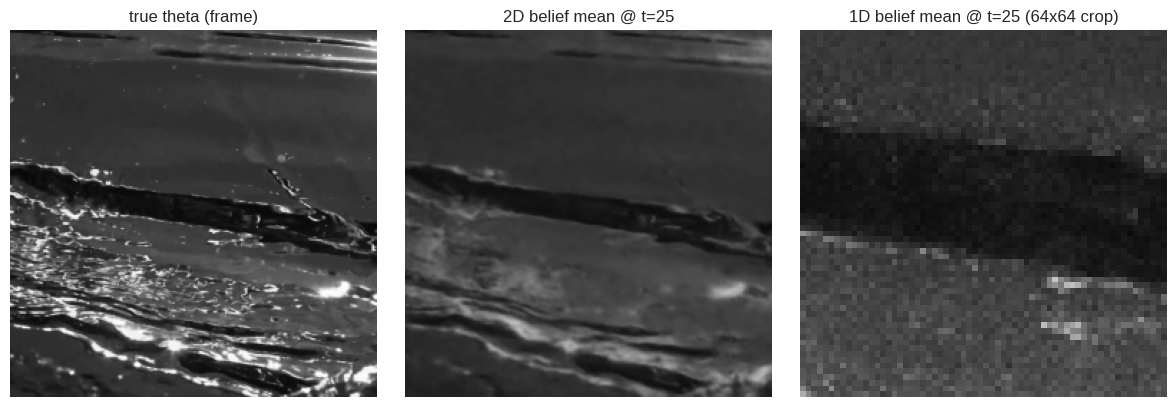

PASS = alpha_med rising steeply as t->0 AND corr@t=25 >= ~0.9 for BOTH nets;
otherwise keep CONJ_ANCHOR_WEIGHT = 1.0 (pure anchor) or retrain zeta longer.


In [15]:
RUN_AVI_PROBE = (INNER_MODE == "conjugate")
if RUN_AVI_PROBE:
    _z2 = zeta_2d if zeta_2d is not None else load_spatial_avi_net(AVI_CHECKPOINT_2D)
    _z1 = zeta_1d if zeta_1d is not None else load_temporal_avi_net(AVI_CHECKPOINT_1D)

    x0_true_t    = torch.tensor(normalize_log_flux(log_flux_vol_true),
                                dtype=torch.float32, device=device).unsqueeze(0)   # [1,T,H,W]
    theta_true_t = torch.tensor(flux_vol_true / 10000.0,
                                dtype=torch.float32, device=device).unsqueeze(0)   # normflux link

    f_idx    = torch.arange(0, VOL_T, VOL_T // 16, device=device)   # 16 frames for the 2D net
    cy0, cx0 = (VOL_H - 64) // 2, (VOL_W - 64) // 2                 # 64x64 crop for the 1D net

    print(f"{'t':>5s} {'net':>4s} {'alpha_med':>10s} {'alpha_p90':>10s} {'corr(mean,theta)':>17s}")
    probe_means = {}
    for t_probe in (25, 200, 800):
        ab  = float(alphas_cumprod_t[t_probe])
        x_p = math.sqrt(ab) * x0_true_t + math.sqrt(1.0 - ab) * torch.randn_like(x0_true_t)
        a2, b2 = gamma_from_2d_avi(x_p[:, f_idx], t_probe, _z2)
        a1, b1 = gamma_from_1d_avi(x_p[:, :, cy0:cy0 + 64, cx0:cx0 + 64], t_probe, _z1)
        for tag, a, b, th_true in (("2D", a2, b2, theta_true_t[:, f_idx]),
                                   ("1D", a1, b1, theta_true_t[:, :, cy0:cy0 + 64, cx0:cx0 + 64])):
            m    = (a / b).flatten().float().cpu().numpy()
            tt   = th_true.flatten().float().cpu().numpy()
            corr = float(np.corrcoef(m, tt)[0, 1])
            print(f"{t_probe:5d} {tag:>4s} {a.median().item():10.2f} "
                  f"{torch.quantile(a.float(), 0.9).item():10.2f} {corr:17.3f}")
            if t_probe == 25:
                probe_means[tag] = (a / b).cpu()

    k2 = len(f_idx) // 2
    fig, axp = plt.subplots(1, 3, figsize=(12, 4))
    axp[0].imshow(theta_true_t[0, f_idx[k2]].cpu(), vmin=0, vmax=1, cmap="gray")
    axp[0].set_title("true theta (frame)")
    axp[1].imshow(probe_means["2D"][0, k2], vmin=0, vmax=1, cmap="gray")
    axp[1].set_title("2D belief mean @ t=25")
    axp[2].imshow(probe_means["1D"][0, VOL_T // 2], vmin=0, vmax=1, cmap="gray")
    axp[2].set_title("1D belief mean @ t=25 (64x64 crop)")
    for a_ in axp:
        a_.axis("off")
    plt.tight_layout(); plt.show()

    print("PASS = alpha_med rising steeply as t->0 AND corr@t=25 >= ~0.9 for BOTH nets;")
    print("otherwise keep CONJ_ANCHOR_WEIGHT = 1.0 (pure anchor) or retrain zeta longer.")
    if zeta_2d is None:
        del _z2
    if zeta_1d is None:
        del _z1
    torch.cuda.empty_cache()
else:
    print("Probe skipped (INNER_MODE != 'conjugate').")

## 12c. Run the DAPS sampler

Inner mode selected by `INNER_MODE`; with `CONJ_ANCHOR_WEIGHT = 1.0` this is the **anchored-exact** variant: PF-ODE $\hat x_0$ from the score priors each step, then the exact pooled Poisson–Gamma draw around it (Tier-A structure, Langevin replaced by one closed-form draw).

In [16]:
# Run DAPS sampler (inner mode via INNER_MODE; prior composition via COMPOSE_MODE).
if COMPOSE_MODE == "poe" and POE_MARG_CORRECT and MARG_FIT_FROM_COUNTS:
    _m, _s = fit_marginal_from_counts(bin_counts_3d_t, bin_sizes_3d_t, ppp_scale_3d)
    print(f"Marginal prior (empirical-Bayes from photon totals): N(m={_m:.3f}, s={_s:.3f}) in x-space")
x0_norm_3d, traj_3d = sample_daps_3d(
    bin_counts=bin_counts_3d_t, bin_sizes=bin_sizes_3d_t, ppp_scale=ppp_scale_3d,
    model_1d=model_1d, model_2d=model_2d, prior_info_2d=prior_info_2d,
    sigma_arr=sigma_arr, alphas_cumprod_t=alphas_cumprod_t,
    vol_shape=(1, VOL_T, VOL_H, VOL_W),
    num_annealing=DAPS_NUM_ANNEALING, num_inner_pfode=DAPS_NUM_INNER_PFODE, num_mcmc=DAPS_NUM_MCMC,
    lr_init=DAPS_LR_INIT, lr_min=DAPS_LR_MIN,
    lambda_data=DAPS_LAMBDA_DATA,
    switch_sigma=SWITCH_SIGMA, temporal_first=TEMPORAL_FIRST,
    blend_h=BLEND_H, blend_band=BLEND_BAND,
    pool_init=POOL_FACTOR_INIT, pool_floor=POOL_FACTOR_FLOOR,
    inner_mode=INNER_MODE, zeta_1d=zeta_1d, zeta_2d=zeta_2d,
    anchor_weight=CONJ_ANCHOR_WEIGHT, rate_link=AVI_RATE_LINK, gamma_eps=AVI_GAMMA_EPS,
    final_mean=CONJ_FINAL_MEAN, anchor_pfode_sigma=ANCHOR_PFODE_SIGMA,
    ula_steps=ULA_CORRECT_STEPS, ula_sigma=ULA_CORRECT_SIGMA, ula_scale=ULA_STEP_SCALE,
    dark_count=DARK_COUNT, log_flux_max=LOG_FLUX_MAX,
    snapshot_every=max(1, DAPS_NUM_ANNEALING // 10), verbose=True,
)

x0_norm_np   = x0_norm_3d[0].detach().cpu().numpy()
log_flux_est = denormalize_log_flux(x0_norm_np)
flux_est_vol = np.exp(log_flux_est)

print(f"\nEstimated flux range=[{flux_est_vol.min():.1f}, {flux_est_vol.max():.1f}]")
print(f"True      flux range=[{flux_vol_true.min():.1f}, {flux_vol_true.max():.1f}]")
vol_corr = np.corrcoef(flux_est_vol.ravel(), flux_vol_true.ravel())[0, 1]
vol_rmse = np.sqrt(np.mean((flux_est_vol - flux_vol_true) ** 2))
print(f"Volume correlation={vol_corr:.4f}  RMSE={vol_rmse:.2f}")

Marginal prior (empirical-Bayes from photon totals): N(m=0.695, s=0.035) in x-space


DAPS-3D (2D<->1D soft-blend, conjugate):   1%|          | 1/100 [02:10<3:35:21, 130.52s/it]

  step   0  t= 999  sigma=157.407  pool= 1  PoE(l2=1/l1=1)  inner=conjugate(anchor_pfode=1)  exp(mean log-flux)=424.9  x0_y[min,max]=[-1.000,1.000]


DAPS-3D (2D<->1D soft-blend, conjugate):  11%|█         | 11/100 [22:50<3:04:08, 124.14s/it]

  step  10  t= 899  sigma=60.271  pool= 1  PoE(l2=1/l1=1)  inner=conjugate(anchor_pfode=1)  exp(mean log-flux)=2005.6  x0_y[min,max]=[-1.000,1.000]


...

DAPS-3D (2D<->1D soft-blend, conjugate):  91%|█████████ | 91/100 [3:08:18<18:37, 124.17s/it]

  step  90  t=  99  sigma=0.339  pool= 1  PoE(l2=1/l1=1)  inner=conjugate(anchor_pfode=1)  exp(mean log-flux)=1.2  x0_y[min,max]=[-1.000,-0.466]


DAPS-3D (2D<->1D soft-blend, conjugate): 100%|██████████| 100/100 [4:24:46<00:00, 158.87s/it]

  step  99  t=   9  sigma=0.044  pool= 1  PoE(l2=1/l1=1)  inner=conjugate(final: mean@pool=1)  exp(mean log-flux)=1.0  x0_y[min,max]=[-1.000,-0.987]



Estimated flux range=[1.0, 1.1]
True      flux range=[137.3, 10000.0]
Volume correlation=0.1714  RMSE=2845.97


## 13. Visualisations (frame, trace, trajectory)

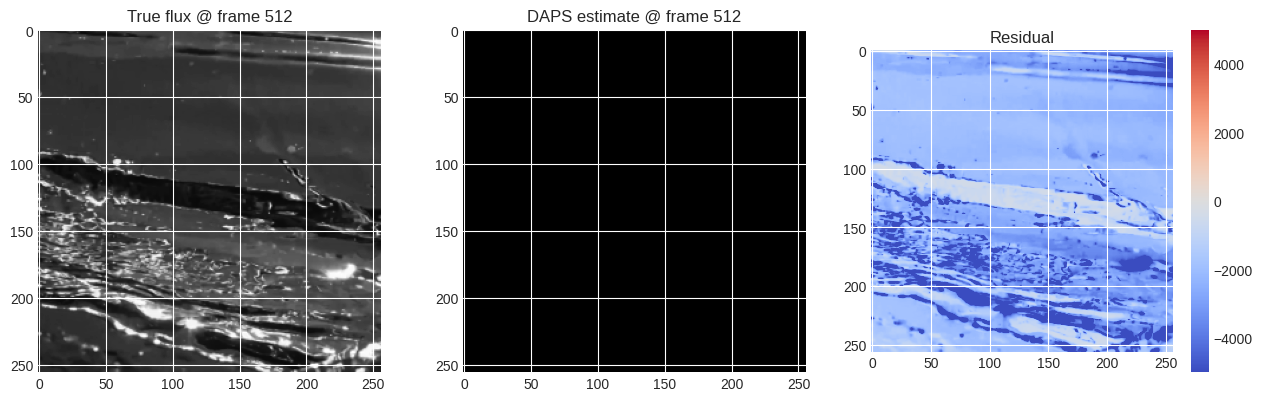

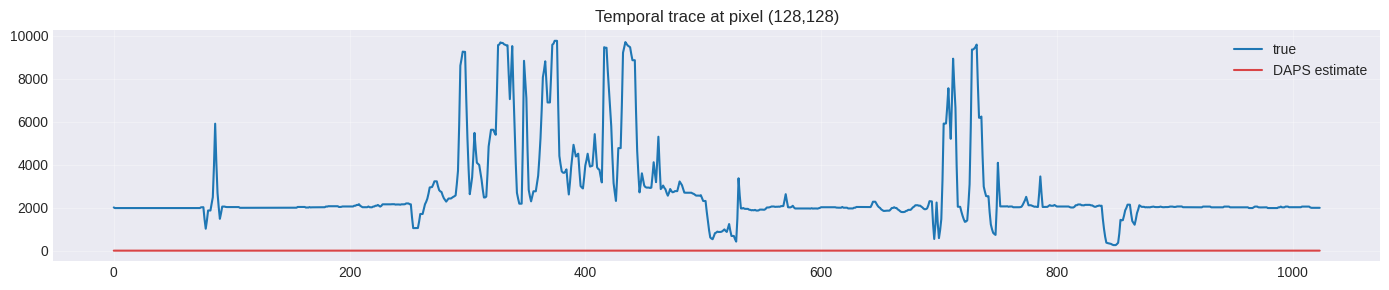

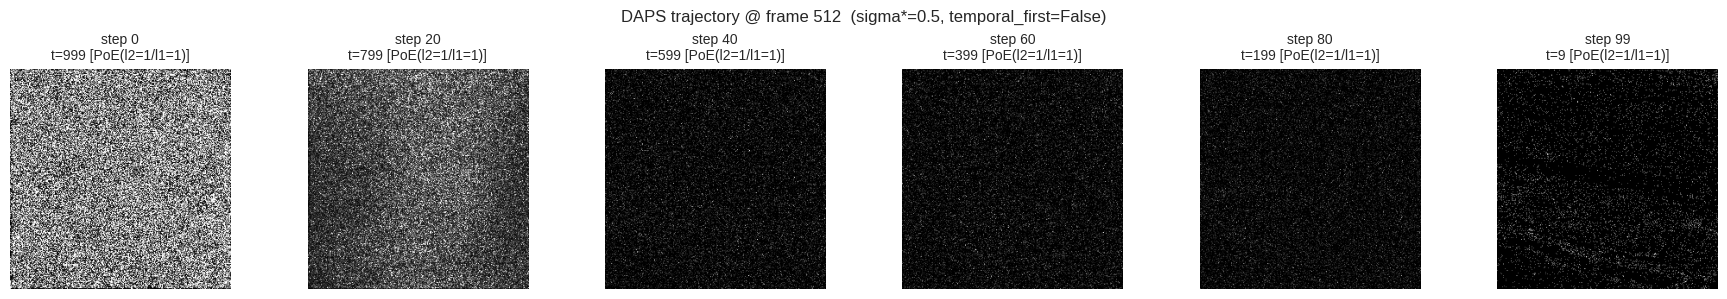

In [17]:
k = VOL_T // 2
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
vmax = max(flux_vol_true[k].max(), flux_est_vol[k].max())
ax[0].imshow(flux_vol_true[k], vmin=0, vmax=vmax, cmap="gray")
ax[0].set_title(f"True flux @ frame {k}")
ax[1].imshow(flux_est_vol[k], vmin=0, vmax=vmax, cmap="gray")
ax[1].set_title(f"DAPS estimate @ frame {k}")
im = ax[2].imshow(flux_est_vol[k] - flux_vol_true[k], cmap="coolwarm", vmin=-vmax / 2, vmax=vmax / 2)
ax[2].set_title("Residual"); plt.colorbar(im, ax=ax[2])
plt.tight_layout(); plt.show()

i, j = VOL_H // 2, VOL_W // 2
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(flux_vol_true[:, i, j], label="true",      color="#1f77b4")
ax.plot(flux_est_vol[:,  i, j], label="DAPS estimate", color="#d62728", alpha=0.85)
ax.set_title(f"Temporal trace at pixel ({i},{j})")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

if len(traj_3d) > 0:
    ncols = min(6, len(traj_3d))
    pick  = np.linspace(0, len(traj_3d) - 1, ncols, dtype=int)
    fig, axes = plt.subplots(1, ncols, figsize=(3 * ncols, 3))
    for ax, idx2 in zip(np.atleast_1d(axes), pick):
        step_idx, t_val, phase, x_snap = traj_3d[idx2]
        frame = np.exp(denormalize_log_flux(x_snap[0, k].numpy()))
        ax.imshow(frame, cmap="gray")
        ax.set_title(f"step {step_idx}\nt={t_val} [{phase}]", fontsize=10)
        ax.axis("off")
    plt.suptitle(f"DAPS trajectory @ frame {k}  (sigma*={SWITCH_SIGMA}, temporal_first={TEMPORAL_FIRST})")
    plt.tight_layout(); plt.show()

## 14. Per-frame image-quality metrics (SSIM / PSNR / LPIPS)

Same protocol as the DiffPIR notebook so numbers can be compared cell-for-cell.

SSIM mean=0.0021  std=0.0007  range=[0.0007, 0.0035]
PSNR mean=11.19 dB  std=2.07  range=[3.34, 13.33]
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/homes/tan583/scratch/condaenvs/DAPS/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/homes/tan583/scratch/condaenvs/DAPS/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /homes/tan583/scratch/condaenvs/DAPS/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth
LPIPS mean=0.8471  std=0.0998  range=[0.4914, 0.9591]


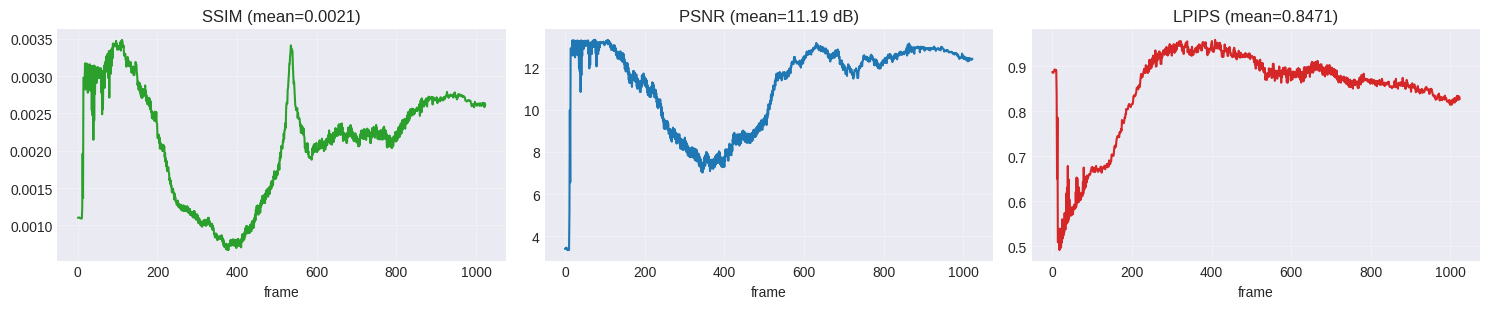

In [18]:
from skimage.metrics import structural_similarity as sk_ssim
try:
    from skimage.metrics import peak_signal_noise_ratio as sk_psnr
except Exception:
    sk_psnr = None

def _psnr_np(x, y, data_range):
    mse = np.mean((x.astype(np.float64) - y.astype(np.float64)) ** 2)
    return float('inf') if mse == 0 else float(20 * np.log10(data_range) - 10 * np.log10(mse))

T_, H_, W_ = flux_vol_true.shape
ssim_pf = np.zeros(T_); psnr_pf = np.zeros(T_)
for t in range(T_):
    gt, es = flux_vol_true[t], flux_est_vol[t]
    scale = max(gt.max(), 1e-8)
    gt_n = np.clip(gt / scale, 0.0, 1.0).astype(np.float32)
    es_n = np.clip(es / scale, 0.0, 1.0).astype(np.float32)
    ssim_pf[t] = sk_ssim(gt_n, es_n, data_range=1.0)
    psnr_pf[t] = sk_psnr(gt_n, es_n, data_range=1.0) if sk_psnr is not None else _psnr_np(gt_n, es_n, 1.0)

print(f"SSIM mean={ssim_pf.mean():.4f}  std={ssim_pf.std():.4f}  range=[{ssim_pf.min():.4f}, {ssim_pf.max():.4f}]")
print(f"PSNR mean={psnr_pf.mean():.2f} dB  std={psnr_pf.std():.2f}  range=[{psnr_pf.min():.2f}, {psnr_pf.max():.2f}]")

lpips_pf = None
try:
    import lpips as _lpips_mod
    if "_lpips_net" not in globals():
        _lpips_net = _lpips_mod.LPIPS(net="alex").to(device).eval()
        globals()["_lpips_net"] = _lpips_net
    lpips_pf = np.zeros(T_); LPIPS_BATCH = 32
    with torch.no_grad():
        for start in range(0, T_, LPIPS_BATCH):
            end = min(start + LPIPS_BATCH, T_)
            gt_chunk, es_chunk = flux_vol_true[start:end], flux_est_vol[start:end]
            scale = np.maximum(gt_chunk.reshape(end - start, -1).max(axis=1), 1e-8)[:, None, None]
            gt_n = np.clip(gt_chunk / scale, 0.0, 1.0).astype(np.float32)
            es_n = np.clip(es_chunk / scale, 0.0, 1.0).astype(np.float32)
            gt_t = torch.from_numpy(gt_n).to(device).unsqueeze(1).repeat(1, 3, 1, 1) * 2 - 1
            es_t = torch.from_numpy(es_n).to(device).unsqueeze(1).repeat(1, 3, 1, 1) * 2 - 1
            lpips_pf[start:end] = _lpips_net(gt_t, es_t).view(-1).cpu().numpy()
    print(f"LPIPS mean={lpips_pf.mean():.4f}  std={lpips_pf.std():.4f}  range=[{lpips_pf.min():.4f}, {lpips_pf.max():.4f}]")
except ImportError:
    print("LPIPS skipped: pip install lpips to enable.")

ncols = 3 if lpips_pf is not None else 2
fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 3.2))
axes[0].plot(ssim_pf, color="#2ca02c"); axes[0].set_title(f"SSIM (mean={ssim_pf.mean():.4f})")
axes[0].set_xlabel("frame"); axes[0].grid(alpha=0.3)
axes[1].plot(psnr_pf, color="#1f77b4"); axes[1].set_title(f"PSNR (mean={psnr_pf.mean():.2f} dB)")
axes[1].set_xlabel("frame"); axes[1].grid(alpha=0.3)
if lpips_pf is not None:
    axes[2].plot(lpips_pf, color="#d62728"); axes[2].set_title(f"LPIPS (mean={lpips_pf.mean():.4f})")
    axes[2].set_xlabel("frame"); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()